In [1]:
GRAY_TO_CLASS = {0: -1, 64: 0, 128: 1, 192: 2, 255: 3}  # -1 = background, ignorado
CLASS_NAMES = ["No_Proliferativo", "Proliferativo", "Esclerosado", "Excluido"]
CONFIG = {
    # Paths — leer desde Entradas/ (tiles crudos + máscaras manuales)
    'images_dir': 'Salidas/Tiles_UNet',              # <slide>/images/*.png — igual que U-Net
    'masks_dir':  'Salidas/Tiles_UNet',              # <slide>/masks/*_mask.png — máscaras multiclase
    'output_dir': 'Salidas/Clasificador',
    # Split — MISMO que U-Net
    'train_size': 0.70,
    'val_size':   0.15,
    'seed':       42,
    # Crop/reconstruction
    'input_size':   224,
    'mask_size':    224,
    'margin_ratio': 0.25,
    'min_area_px':  1500,
    'min_distance': 15,
    'force_rebuild_manifest': False,  # True para ignorar Salidas/Clasificador/manifest.csv y reconstruirlo
    'manifest_primary_only': True,     # Usar solo glomérulos primary del annotations.json
    # Model
    'backbone':    'efficientnet_b0',
    'input_mode':  'rgb_mask_manual',
    'num_classes': 4,
    'pretrained':  True,
    # Training
    'max_epochs':      60,
    'batch_size':  32,
    'lr':          1e-3,
    'weight_decay': 1e-4,
    'warmup_epochs': 5,
    'use_amp':     True,
    'early_stopping_patience': 10,
    'early_stopping_min_delta': 1e-4,
    # Sampling & Loss strategy
    'sampling_strategy': 'sampler_balanced_ce_unweighted',
}


In [2]:
# Standard library
import os
import json
import random
import warnings
from pathlib import Path
from typing import Tuple
# Scientific computing / ML
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import albumentations as A
import timm
import matplotlib.pyplot as plt
# Data loading and metrics
from PIL import Image, ImageFile
from scipy.ndimage import label as scipy_label, distance_transform_edt
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, precision_recall_fscore_support, accuracy_score
from skimage.feature import peak_local_max as _plm
from skimage.measure import regionprops
from skimage.segmentation import watershed as _watershed
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tqdm.auto import tqdm
import scipy
# Allow PIL to load truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True
# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
# --- CUDA performance tuning (T4 Tensor Cores) ---
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True          # auto-tune conv algorithms
    torch.backends.cuda.matmul.allow_tf32 = True   # TF32 for matmul (T4 supports it)
    torch.backends.cudnn.allow_tf32 = True         # TF32 for cudnn convolutions
    print(f"cudnn.benchmark: {torch.backends.cudnn.benchmark}")
    print(f"CUDA matmul TF32: {torch.backends.cuda.matmul.allow_tf32}")
    print(f"cudnn TF32: {torch.backends.cudnn.allow_tf32}")
    print(f"PYTORCH_CUDA_ALLOC_CONF: expandable_segments:True")
# --- Preprocessing Transforms (Reinhard Normalization + Z-score) ---
class ReinhardNormalize:
    """Reinhard stain normalization in LAB color space for consistency across slides."""
    def __init__(self, target_stats: dict):
        self.target = target_stats
    @staticmethod
    def _get_tissue_mask(img_bgr: np.ndarray) -> np.ndarray:
        """Isolate tissue pixels from background and artifacts via luminance and saturation thresholds."""
        lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
        hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
        mask = (lab[:, :, 0] < 230) & (hsv[:, :, 1] > 10)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
        mask = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        return mask.astype(bool)
    @staticmethod
    def compute_template_stats(image_paths: list, n_samples: int = 200) -> dict:
        """Compute median LAB statistics from tissue pixels to define normalization target."""
        paths_list = list(image_paths)[:n_samples]
        sample = random.sample(paths_list, min(n_samples, len(paths_list)))
        all_stats = []
        
        for p in sample:
            img = cv2.imread(str(p))
            if img is None:
                continue
            tissue = ReinhardNormalize._get_tissue_mask(img)
            if tissue.sum() < 100:
                continue
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)
            stats = ([lab[..., c][tissue].mean() for c in range(3)] +
                     [lab[..., c][tissue].std()  for c in range(3)])
            all_stats.append(stats)
        
        if not all_stats:
            return {'mean_L': 50, 'mean_a': 128, 'mean_b': 128,
                    'std_L': 10, 'std_a': 10, 'std_b': 10}
        
        arr = np.array(all_stats)
        keys = ['mean_L', 'mean_a', 'mean_b', 'std_L', 'std_a', 'std_b']
        return {k: float(np.median(arr[:, i])) for i, k in enumerate(keys)}
    def __call__(self, img_bgr: np.ndarray) -> np.ndarray:
        """Normalize image to match template statistics, preserving background pixels."""
        tissue = self._get_tissue_mask(img_bgr)
        if tissue.sum() < 100:
            return img_bgr
        
        lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
        
        src = {c: (lab[..., i][tissue].mean(), lab[..., i][tissue].std())
               for i, c in enumerate(['L', 'a', 'b'])}
        
        result = lab.copy()
        for i, c in enumerate(['L', 'a', 'b']):
            m, s = src[c]
            result[..., i] = ((lab[..., i] - m) *
                              (self.target[f'std_{c}'] / (s + 1e-5)) +
                              self.target[f'mean_{c}'])
        
        result[~tissue] = lab[~tissue]
        result = np.clip(result, 0, 255).astype(np.uint8)
        return cv2.cvtColor(result, cv2.COLOR_LAB2BGR)
def compute_channel_stats(
    image_paths: list,
    n_samples: int = 200,
    reinhard_norm=None,
    std_floor: float = 0.03,
) -> Tuple[list, list]:
    """Compute weighted per-channel RGB stats from tissue pixels for Z-score normalization."""
    paths_list = list(image_paths)
    sample = random.sample(paths_list, min(n_samples, len(paths_list)))
    
    tile_means, tile_vars, tile_counts = [], [], []
    skipped_count = 0
    for p in sample:
        img_bgr = cv2.imread(str(p))
        if img_bgr is None:
            skipped_count += 1
            continue
        tissue = ReinhardNormalize._get_tissue_mask(img_bgr)
        if tissue.sum() < 100:
            skipped_count += 1
            continue
        if reinhard_norm is not None:
            img_bgr = reinhard_norm(img_bgr)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        pixels = img_rgb[tissue]
        tile_means.append(pixels.mean(0))
        tile_vars.append(pixels.var(0))
        tile_counts.append(tissue.sum())
    
    if not tile_means:
        print(f"  ⚠️  WARNING: No valid tissue pixels found in {len(sample)} samples!")
        print(f"      {skipped_count} samples were skipped (tissue.sum() < 100 or read failed)")
        print(f"      Falling back to default values [0.5, 0.5, 0.5] and [0.2, 0.2, 0.2]")
        print(f"      This will make Z-score normalization INEFFECTIVE.")
        return [0.5, 0.5, 0.5], [0.2, 0.2, 0.2]
    
    print(f"  ✓ Computed stats from {len(tile_means)} valid samples (skipped {skipped_count})")
    
    means_arr = np.array(tile_means)
    vars_arr = np.array(tile_vars)
    counts_arr = np.array(tile_counts, dtype=np.float64)
    w = counts_arr / counts_arr.sum()
    
    mean = (means_arr * w[:, None]).sum(0)
    var = ((vars_arr + (means_arr - mean) ** 2) * w[:, None]).sum(0)
    std = np.sqrt(var)
    std = np.maximum(std, std_floor)
    return mean.tolist(), std.tolist()
def _collect_image_tiles(images_dir: str) -> list:
    """Collect input PNG tiles while excluding masks and generated mask files."""
    images_dir = Path(images_dir)
    image_paths = sorted(images_dir.glob('*/images/*.png'))
    # Fallback for flat/custom datasets: include PNGs except anything inside a masks folder
    # or files already named *_mask.png.
    if not image_paths:
        image_paths = sorted(
            p for p in images_dir.rglob('*.png')
            if 'masks' not in p.relative_to(images_dir).parts
            and not p.stem.endswith('_mask')
        )
    return image_paths
def _slide_name_from_image_path(image_path, images_dir) -> str:
    """Infer the biopsy/slide name from a tile path under <root>/<slide>/images/*.png."""
    image_path = Path(image_path)
    images_dir = Path(images_dir)
    try:
        rel = image_path.relative_to(images_dir)
        if len(rel.parts) >= 3 and rel.parts[1] == 'images':
            return rel.parts[0]
    except ValueError as e:
        warnings.warn(f'Path format issue for {image_path}: {e}')
        return None
    if image_path.parent.name == 'images' and image_path.parent.parent.name:
        return image_path.parent.parent.name
    return image_path.parent.name or image_path.stem
def _group_images_by_biopsy(image_paths: list, images_dir: str) -> dict:
    """Group image paths by biopsy/slide folder, supporting canonical and flat layouts."""
    images_dir = Path(images_dir)
    biopsias_dict = {}
    for img_path in image_paths:
        biopsia = _slide_name_from_image_path(img_path, images_dir)
        biopsias_dict.setdefault(biopsia, []).append(img_path)
    return biopsias_dict
def _safe_train_val_test_split(
    biopsias_list: list,
    train_size: float = 0.70,
    val_size: float = 0.15,
    seed: int = 42,
) -> Tuple[list, list, list]:
    """Split biopsy IDs without crashing on tiny datasets."""
    test_size = 1.0 - train_size - val_size
    assert test_size >= 0, "train_size + val_size must be <= 1.0"
    biopsias_list = list(biopsias_list)
    if not biopsias_list:
        return [], [], []
    # sklearn.train_test_split raises on very small lists. Keep deterministic, leak-free
    # biopsy-level splits and prefer having train data in quick/smoke-test datasets.
    if len(biopsias_list) == 1:
        return biopsias_list, [], []
    if len(biopsias_list) == 2:
        rng = random.Random(seed)
        shuffled = biopsias_list[:]
        rng.shuffle(shuffled)
        return [shuffled[0]], [shuffled[1]], []
    if test_size > 0:
        train_val_biopsias, test_biopsias = train_test_split(
            biopsias_list,
            test_size=test_size,
            random_state=seed,
        )
    else:
        train_val_biopsias = biopsias_list
        test_biopsias = []
    if val_size > 0 and len(train_val_biopsias) > 1:
        val_fraction = val_size / (train_size + val_size)
        train_biopsias, val_biopsias = train_test_split(
            train_val_biopsias,
            test_size=val_fraction,
            random_state=seed + 1,
        )
    else:
        train_biopsias = train_val_biopsias
        val_biopsias = []
    return train_biopsias, val_biopsias, test_biopsias
def split_biopsias(
    images_dir: str,
    train_size: float = 0.70,
    val_size: float = 0.15,
    seed: int = 42,
) -> Tuple[list, list, list, dict]:
    """Groups biopsias into train/val/test to prevent data leakage at slide level."""
    images_dir = Path(images_dir)
    all_images = _collect_image_tiles(images_dir)
    if not all_images:
        raise ValueError(f"No PNG image tiles found in {images_dir}. Expected files under */images/*.png")
    biopsias_dict = _group_images_by_biopsy(all_images, images_dir)
    train_biopsias, val_biopsias, test_biopsias = _safe_train_val_test_split(
        list(biopsias_dict.keys()),
        train_size=train_size,
        val_size=val_size,
        seed=seed,
    )
    return train_biopsias, val_biopsias, test_biopsias, biopsias_dict
def load_rgb_image(image_path: str) -> np.ndarray:
    """Load an RGB uint8 image with PIL tolerance for truncated files."""
    try:
        return np.array(Image.open(str(image_path)).convert('RGB'))
    except Exception as exc:
        raise RuntimeError(f"Failed to load image {image_path}: {exc}") from exc
def load_binary_mask(mask_path: str) -> np.ndarray:
    """Load a grayscale mask and binarize all non-zero classes as glomerulus."""
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise RuntimeError(f"Failed to load mask: {mask_path}")
    return (mask > 0).astype(np.uint8)
def preprocess_rgb_image(
    img_rgb: np.ndarray,
    reinhard_norm=None,
    channel_means: list = None,
    channel_stds: list = None,
    reinhard=None,
) -> np.ndarray:
    """Apply the same RGB -> Reinhard -> RGB/255 -> Z-score preprocessing used by the dataset.

    `reinhard` is accepted as an alias because the classifier Dataset stores the
    checkpoint stats under that name. It can be either a ReinhardNormalize object
    or the raw target-stats dict loaded from the U-Net checkpoint.
    """
    if reinhard_norm is None and reinhard is not None:
        reinhard_norm = ReinhardNormalize(reinhard) if isinstance(reinhard, dict) else reinhard

    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    if reinhard_norm is not None:
        img_bgr = reinhard_norm(img_bgr)
    img_float = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    if channel_means is not None and channel_stds is not None:
        means = np.asarray(channel_means, dtype=np.float32)
        stds = np.asarray(channel_stds, dtype=np.float32)
        img_float = (img_float - means) / (stds + 1e-6)
    return img_float
def make_mask_overlay(img_rgb: np.ndarray, mask_binary: np.ndarray, color=(255, 0, 0), alpha: float = 0.4) -> np.ndarray:
    """Blend a binary mask over an RGB image."""
    overlay = img_rgb.copy().astype(np.float32)
    overlay[mask_binary.astype(bool)] = color
    return cv2.addWeighted(img_rgb, 1 - alpha, overlay.astype(np.uint8), alpha, 0)
# ============================================================================
# Grayscale pixel values that correspond to glomerulus classes (any > 0 in practice)
# 64=No_Proliferativo, 128=Proliferativo, 192=Esclerosado, 255=Excluido/Excluyente
# Excluido (255) is INTENTIONALLY mapped to Glomerulus class 1 for binary segmentation
# ============================================================================
# ===== CENTRALIZED POST-PROCESSING FUNCTION =====
# This function is used by threshold tuning, crop extraction, and reconstruction viz
# to ensure CONSISTENCY across all stages
def postprocess_prob_to_instances(
    prob_map,           # H×W float32 probability map (0-1)
    threshold=0.4,
    min_area_px=1500,
    min_distance=15,    # distance between watershed peaks
):
    """
    Consistent post-processing pipeline for all glomerulus detection tasks.
    
    Args:
        prob_map: H×W float32 array in [0, 1]
        threshold: decision threshold
        min_area_px: minimum instance area in pixels
        min_distance: minimum distance between watershed peaks
    
    Returns:
        list of skimage regionprops objects (instances)
    """
    # Step 1: Binary mask from probability
    binary_mask = (prob_map > threshold).astype(np.uint8)
    
    # Step 2: Morphological cleaning (close → open)
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel_close)
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel_open)
    
    # Step 3: Watershed-based instance separation
    if binary_mask.sum() < min_area_px:
        return []
    
    distance = distance_transform_edt(binary_mask)
    coords = _plm(distance, min_distance=min_distance, labels=binary_mask)
    
    if len(coords) == 0:
        # Single large region
        coords = np.array([[binary_mask.shape[0]//2, binary_mask.shape[1]//2]])
    
    marker_mask = np.zeros_like(binary_mask, dtype=bool)
    marker_mask[tuple(coords.T)] = True
    markers, _ = scipy_label(marker_mask)
    
    labels_map = _watershed(-distance, markers, mask=binary_mask)
    props = regionprops(labels_map)
    
    # Step 4: Filter by minimum area
    return [p for p in props if p.area >= min_area_px]


c:\Users\proyecto_final\Documents\Proyecto_Final_Glomerulos\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: Tesla T4
VRAM: 17.00 GB
cudnn.benchmark: True
CUDA matmul TF32: True
cudnn TF32: True
PYTORCH_CUDA_ALLOC_CONF: expandable_segments:True


In [3]:
def extract_crop_with_margin(img: np.ndarray, bbox: Tuple[int, int, int, int], margin_ratio: float = 0.25) -> np.ndarray:
    """Extract crop from image with margin around bounding box.
    
    Args:
        img: Image array (H x W or H x W x C)
        bbox: [r_min, c_min, r_max, c_max] bounding box
        margin_ratio: Fraction of height/width to add as margin (default 0.25)
    
    Returns:
        Cropped image array
    """
    h, w = bbox[2] - bbox[0], bbox[3] - bbox[1]
    mh = int(h * margin_ratio)
    mw = int(w * margin_ratio)
    r_min = max(0, bbox[0] - mh)
    r_max = min(img.shape[0], bbox[2] + mh)
    c_min = max(0, bbox[1] - mw)
    c_max = min(img.shape[1], bbox[3] + mw)
    return img[r_min:r_max, c_min:c_max]
def perturb_mask(binary_mask: np.ndarray) -> np.ndarray:
    """Perturba la máscara binaria para simular error de U-Net en entrenamiento."""
    ops = random.choices(['dilate', 'erode', 'close', 'open', 'shift', 'none'], k=1)[0]
    # Handle branches that don't need kernel first
    if ops == 'none':
        return binary_mask
    if ops == 'shift':
        dx, dy = random.randint(-5, 5), random.randint(-5, 5)
        M = np.float32([[1, 0, dx], [0, 1, dy]])
        shifted = cv2.warpAffine(binary_mask.astype(np.uint8), M, binary_mask.shape[::-1])
        return shifted.astype(bool)
    # Create kernel only when needed by morphological operations
    k = random.choice([3, 5])
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    if ops == 'dilate':
        return cv2.dilate(binary_mask.astype(np.uint8), kernel).astype(bool)
    elif ops == 'erode':
        return cv2.erode(binary_mask.astype(np.uint8), kernel).astype(bool)
    elif ops == 'close':
        return cv2.morphologyEx(binary_mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel).astype(bool)
    elif ops == 'open':
        return cv2.morphologyEx(binary_mask.astype(np.uint8), cv2.MORPH_OPEN, kernel).astype(bool)
    return binary_mask


In [4]:
def build_glomerulus_manifest(
    images_dir: str,
    masks_dir: str,
    split_biopsias_result: dict,  # {'train': [...], 'val': [...], 'test': [...]}
    min_area_px: int = 1500,
    min_distance: int = 15,
    output_csv: str = None,
) -> pd.DataFrame:
    """
    Enumerate ALL glomerulus instances in the dataset (train+val+test).
    Each row is one glomerulus instance with its metadata, bbox, and class.
    
    Algorithm:
    1. For each split ('train', 'val', 'test'):
       - For each biopsia in split:
         - Enumerate tiles: {images_dir}/{biopsia}/images/*.png
         - For EACH tile:
           a. Load mask_gray = load_binary_mask(mask_path, binary=False)
              (PNG uint8 with values 0/64/128/192/255)
           b. Binarize: binary_mask = (mask_gray > 0).astype(float)
           c. Run instance detection: instances = postprocess_prob_to_instances(...)
           d. For EACH instance:
              - Extract bbox: instance.bbox → (r1, c1, r2, c2)
              - Extract region from mask_gray: mask_crop = mask_gray[r1:r2, c1:c2]
              - Find dominant (most frequent) value: dominant = bincount(mask_crop.flatten()).argmax()
              - Map to class: class_id = GRAY_TO_CLASS[dominant] (skip if -1/background)
              - Add row with: slide_id, tile_path, mask_path, instance_id, class_name, 
                             class_id, gray_value, bbox coords, split
    
    2. Return DataFrame with all rows
    3. If output_csv not None, save to CSV
    
    Args:
        images_dir: Root directory with {biopsia}/images/*.png structure
        masks_dir: Root directory with {biopsia}/masks/*_mask.png structure
        split_biopsias_result: dict with keys 'train', 'val', 'test' → list of biopsia names
        min_area_px: Minimum instance area in pixels (default 1500)
        min_distance: Minimum distance between watershed peaks (default 15)
        output_csv: If not None, save manifest to this CSV path
    
    Returns:
        pd.DataFrame with columns:
        - slide_id: biopsia name
        - tile_path: absolute path to tile PNG
        - mask_path: absolute path to mask PNG
        - instance_id: index within tile (0, 1, 2, ...)
        - class_name: CLASS_NAMES[class_id]
        - class_id: int 0-3
        - gray_value: dominant gray value (64, 128, 192, 255)
        - bbox_r1, bbox_c1, bbox_r2, bbox_c2: bounding box coordinates
        - split: 'train'/'val'/'test'
    
    Validation:
        - DataFrame has ~100s-1000s rows (1 per glomerulus, not per tile)
        - All columns present
        - No NaN in critical columns
        - Split distribution: ~70% train, ~15% val, ~15% test (approximate)
    """
    images_dir = Path(images_dir)
    masks_dir = Path(masks_dir)
    
    manifest_rows = []
    
    # Iterate through all splits
    for split_name in ['train', 'val', 'test']:
        biopsias = split_biopsias_result.get(split_name, [])
        
        for biopsia in biopsias:
            # Find all tiles in this biopsia: {images_dir}/{biopsia}/images/*.png
            tiles_glob = sorted((images_dir / biopsia / 'images').glob('*.png'))
            
            for tile_path in tiles_glob:
                # Construct corresponding mask path
                tile_stem = tile_path.stem
                mask_path = masks_dir / biopsia / 'masks' / f'{tile_stem}_mask.png'
                
                # Check if mask exists
                if not mask_path.exists():
                    warnings.warn(f"Mask not found for tile {tile_path}, skipping.")
                    continue
                
                # Load mask as grayscale (uint8, not binarized)
                try:
                    mask_gray = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
                    if mask_gray is None:
                        warnings.warn(f"Failed to load mask: {mask_path}")
                        continue
                except Exception as e:
                    warnings.warn(f"Error loading mask {mask_path}: {e}")
                    continue
                
                # Binarize: any non-zero value is glomerulus
                binary_mask = (mask_gray > 0).astype(float)
                
                # Run instance detection
                instances = postprocess_prob_to_instances(
                    binary_mask,
                    threshold=0.5,
                    min_area_px=min_area_px,
                    min_distance=min_distance,
                )
                
                # Get label image for instance indexing
                label_im, num_labels = scipy_label(binary_mask)
                
                # For each detected instance, extract metadata
                for instance_id, instance in enumerate(instances):
                    # Extract bounding box
                    r1, c1, r2, c2 = instance.bbox
                    
                    # Get pixels for THIS instance only (using label_im directly)
                    # Instance labels start at 1, so we use instance_id + 1
                    instance_label = instance_id + 1
                    instance_pixels = mask_gray[label_im == instance_label]
                    if len(instance_pixels) == 0:
                        continue
                    valid_pixels = instance_pixels[instance_pixels > 0]
                    if len(valid_pixels) == 0:
                        continue
                    dominant = int(np.bincount(valid_pixels).argmax())
                    
                    # Map to class
                    class_id = GRAY_TO_CLASS.get(dominant, -1)
                    
                    # Skip background/unknown classes
                    if class_id == -1:
                        continue
                    
                    class_name = CLASS_NAMES[class_id]
                    
                    # Add row to manifest
                    manifest_rows.append({
                        'slide_id': biopsia,
                        'tile_path': str(tile_path.absolute()),
                        'mask_path': str(mask_path.absolute()),
                        'instance_id': instance_id,
                        'class_name': class_name,
                        'class_id': class_id,
                        'gray_value': int(dominant),
                        'bbox_r1': int(r1),
                        'bbox_c1': int(c1),
                        'bbox_r2': int(r2),
                        'bbox_c2': int(c2),
                        'split': split_name,
                    })
    
    # Build DataFrame
    df = pd.DataFrame(manifest_rows)
    
    # Validation
    if df.empty:
        warnings.warn("No glomerulus instances found. Manifest is empty.")
        return df
    
    # Check for NaN in critical columns
    critical_cols = ['slide_id', 'tile_path', 'mask_path', 'instance_id', 
                     'class_id', 'gray_value', 'split']
    for col in critical_cols:
        if col not in df.columns:
            raise ValueError(f"Missing critical column: {col}")
        if df[col].isna().any():
            raise ValueError(f"Found NaN values in critical column: {col}")
    
    # Log statistics
    split_counts = df['split'].value_counts()
    print(f"\nGlomerulus Manifest Summary:")
    print(f"  Total instances: {len(df)}")
    print(f"  Split distribution:")
    for split in ['train', 'val', 'test']:
        count = split_counts.get(split, 0)
        pct = 100.0 * count / len(df) if len(df) > 0 else 0.0
        print(f"    {split}: {count} ({pct:.1f}%)")
    
    class_counts = df['class_id'].value_counts().sort_index()
    print(f"  Class distribution:")
    for class_id in sorted(class_counts.index):
        count = class_counts[class_id]
        pct = 100.0 * count / len(df)
        class_name = CLASS_NAMES[class_id]
        print(f"    {class_id} ({class_name}): {count} ({pct:.1f}%)")
    
    # Save to CSV if requested
    if output_csv is not None:
        output_path = Path(output_csv)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(output_path, index=False)
        print(f"\n  ✓ Manifest saved to {output_path}")
    
    return df

def _mask_component_candidates(binary_mask: np.ndarray):
    """Return connected-component candidates with bbox, area, centroid, and edge-touch flags."""
    labels, n_labels = scipy_label(binary_mask.astype(np.uint8))
    if n_labels == 0:
        return []

    h, w = binary_mask.shape[:2]
    candidates = []
    for component_id in range(1, n_labels + 1):
        rr, cc = np.where(labels == component_id)
        if len(rr) == 0:
            continue
        r1, c1, r2, c2 = int(rr.min()), int(cc.min()), int(rr.max()) + 1, int(cc.max()) + 1
        area = int(len(rr))
        centroid_r = float(rr.mean())
        centroid_c = float(cc.mean())
        touches_edge = bool(r1 == 0 or c1 == 0 or r2 >= h or c2 >= w)
        candidates.append({
            'component_id': int(component_id),
            'bbox': (r1, c1, r2, c2),
            'area_px': area,
            'centroid_r': centroid_r,
            'centroid_c': centroid_c,
            'touches_edge': touches_edge,
        })
    return candidates


def _select_glomerulus_component(binary_mask: np.ndarray, tile: dict = None, glomerulus: dict = None):
    """
    Select the mask component most likely to match the JSON glomerulus for this tile.

    The mask is semantic/multiclass, not instance-labeled. When a tile contains more
    than one component of the same class, the safest proxy is: prefer high-area
    components close to the tile center, because primary/centered tiles are generated
    around the target glomerulus; penalize edge-touching partial components.
    """
    candidates = _mask_component_candidates(binary_mask)
    if not candidates:
        return None

    h, w = binary_mask.shape[:2]
    center_r, center_c = h / 2.0, w / 2.0
    max_area = max(c['area_px'] for c in candidates)
    diag = float(np.hypot(h, w)) + 1e-6

    for c in candidates:
        dist = float(np.hypot(c['centroid_r'] - center_r, c['centroid_c'] - center_c))
        area_score = c['area_px'] / max(max_area, 1)
        center_score = 1.0 - min(dist / (0.5 * diag), 1.0)
        edge_penalty = 0.15 if c['touches_edge'] else 0.0
        # Area matters most, but center proximity avoids choosing a different same-class glomerulus.
        c['center_distance_px'] = dist
        c['selection_score'] = 0.70 * area_score + 0.30 * center_score - edge_penalty

    candidates = sorted(candidates, key=lambda x: x['selection_score'], reverse=True)
    selected = candidates[0]
    selected['n_components_same_class'] = len(candidates)
    selected['component_rank'] = 1
    return selected


def _largest_component_bbox_and_area(binary_mask: np.ndarray):
    """Backward-compatible helper: return (bbox, area) for the largest connected component."""
    candidates = _mask_component_candidates(binary_mask)
    if not candidates:
        return None, 0
    selected = max(candidates, key=lambda c: c['area_px'])
    return selected['bbox'], selected['area_px']


def build_glomerulus_manifest_from_annotations(
    images_dir: str,
    split_biopsias_result: dict,
    output_csv: str = None,
    primary_only: bool = True,
    classifier_input_size: int = 224,
    force_single_tile_per_glomerulus: bool = False,
    crop_padding_px: int = 128,
    min_component_px: int = 100,
) -> pd.DataFrame:
    """
    Build the classifier manifest from Salidas/Tiles_UNet/{biopsia}/annotations.json
    by FUSING TILES per glomerulus_id.

    **Key Difference from Previous Version:**
    - OLD: One row per (tile, glomerulus_id) → fragmentary glomeruli when gid appears in 2+ tiles
    - NEW: One row per glomerulus_id → reconstructed glomerulus from primary + secondary tiles
    
    **Algorithm:**
    1. For each biopsia in split_biopsias_result:
       a. Load annotations.json → get canvas size (width_native, height_native),
          glomeruli_coverage dict, and tiles list
       b. Group tiles by glomerulus_id using glomeruli_coverage
       c. For each glomerulus_id:
          - Get primary_tile and secondary_tile names from glomeruli_coverage
          - Create native-sized canvas (width_native × height_native, all 0)
          - For each contributing tile (primary + secondary if present):
            * Load tile's mask PNG
            * Extract class-specific pixels (mask == gray_value)
            * Place pixels at tile's bbox_native position on canvas
          - Find the bounding box of all merged mask pixels
          - Crop merged mask to bbox
          - Resize crop to classifier_input_size × classifier_input_size
          - Extract area_px from bbox before resize
       d. Create one row with fused glomerulus metadata

    2. Return DataFrame with columns:
       - Core: slide_id, glomerulus_id, class_name, class_id, gray_value, split
       - Tile fusion: n_tiles_in_glomerulus, glomerulus_tiles (list), primary_coverage_pct, secondary_coverage_pct
       - Bbox (native coords): bbox_r1, bbox_c1, bbox_r2, bbox_c2 (BEFORE resize)
       - area_px (native pixels before resize)
       - Paths: annotations_json (for traceability)
    
    Args:
        images_dir: Root directory with {biopsia}/annotations.json
        split_biopsias_result: dict with keys 'train', 'val', 'test' → list of biopsia names
        output_csv: If not None, save manifest to this CSV path
        primary_only: If True, only include glomeruli with a primary tile (standard classifier use)
        classifier_input_size: Target size for classifier input (e.g., 512)
        force_single_tile_per_glomerulus: If True, only use primary tile (no secondary fusion)
                                          Useful for debugging or comparing against old code.

    Returns:
        pd.DataFrame with one row per glomerulus_id (not per tile)

    Validation:
        - DataFrame has ~100s-1000s rows (1 per glomerulus, not per tile)
        - All glomeruli_ids are unique
        - n_tiles_in_glomerulus ∈ {1, 2}
        - No NaN in critical columns
    """
    images_dir = Path(images_dir)
    crop_padding_px = int(crop_padding_px)
    if not (0 <= crop_padding_px <= 256):
        raise ValueError(
            f"crop_padding_px must be in [0, 256], got {crop_padding_px}. "
            "Check the 'crop_padding_px' key in config.yaml."
        )
    rows = []

    for split_name in ['train', 'val', 'test']:
        for biopsia in split_biopsias_result.get(split_name, []):
            slide_dir = images_dir / biopsia
            annotations_path = slide_dir / 'annotations.json'
            if not annotations_path.exists():
                warnings.warn(f"annotations.json not found for biopsia {biopsia}: {annotations_path}")
                continue

            try:
                annotations = json.loads(annotations_path.read_text())
            except Exception as e:
                warnings.warn(f"Could not read {annotations_path}: {e}")
                continue

            # Extract metadata from annotations
            width_native = annotations.get('width_native')
            height_native = annotations.get('height_native')
            class_gray_values = annotations.get('class_gray_values', {})
            glomeruli_coverage = annotations.get('glomeruli_coverage', {})
            tiles_list = annotations.get('tiles', [])

            if not width_native or not height_native:
                warnings.warn(f"Missing width_native or height_native in {annotations_path}")
                continue

            # Build a lookup: tile_name → tile dict (for reference, though not used in new logic)
            tile_by_name = {}
            for tile in tiles_list:
                tile_name = tile.get('image')
                if tile_name:
                    tile_name_stem = Path(tile_name).stem
                    tile_by_name[tile_name_stem] = tile

            # Build inverted index: glomerulus_id → [all tiles containing it]
            # This captures ALL tiles, not just primary+secondary from glomeruli_coverage
            gid_to_tiles: dict = {}
            for tile in tiles_list:
                for ginfo in tile.get('glomeruli', []):
                    gid = str(ginfo['id'])
                    gid_to_tiles.setdefault(gid, []).append(tile)

            # Process each glomerulus_id from glomeruli_coverage
            for glomerulus_id, coverage_info in glomeruli_coverage.items():
                class_name = coverage_info.get('class')
                gray_value = int(class_gray_values.get(class_name, 0))
                class_id = CLASS_NAMES.index(class_name) if class_name in CLASS_NAMES else GRAY_TO_CLASS.get(gray_value, -1)

                if class_id == -1 or gray_value == 0:
                    continue

                # Get tile names from coverage
                primary_tile_name = coverage_info.get('primary_tile')
                secondary_tile_name = coverage_info.get('secondary_tile') if not force_single_tile_per_glomerulus else None

                if not primary_tile_name:
                    warnings.warn(f"Glomerulus {glomerulus_id} has no primary_tile in {biopsia}")
                    continue

                if primary_only and secondary_tile_name is None and coverage_info.get('primary_coverage_pct', 100.0) < 95:
                    # Optional: skip fragmented primary-only glomeruli
                    pass

                # **SMART TILE SELECTION**:
                # If primary tile has high coverage (>=95%), use ONLY the primary tile to avoid adding noise
                # Otherwise, use all tiles that contain this glomerulus
                primary_coverage_pct = float(coverage_info.get('primary_coverage_pct', 0.0))

                # Always use ALL tiles for this glomerulus (removed 95% threshold)
                # This ensures even small fragments in neighboring tiles are included
                contributing_tiles = gid_to_tiles.get(str(glomerulus_id), [])

                                # **FUSE TILES: Create canvas, load and place each tile's mask AND RGB image, merge**
                # Compute glomerulus bounding box from all contributing tiles
                all_bboxes = [tile['bbox_native'] for tile in contributing_tiles if tile.get('bbox_native')]
                if not all_bboxes:
                    warnings.warn(f"No valid bbox_native in contributing tiles for glomerulus {glomerulus_id} in {biopsia}")
                    continue

                gx1 = max(0, min(int(b[0]) for b in all_bboxes))
                gy1 = max(0, min(int(b[1]) for b in all_bboxes))
                gx2 = min(width_native, max(int(b[2]) for b in all_bboxes))
                gy2 = min(height_native, max(int(b[3]) for b in all_bboxes))
                
                # Apply crop padding to glomerulus bbox
                pad = crop_padding_px
                gx1 = max(0, gx1 - pad)
                gy1 = max(0, gy1 - pad)
                gx2 = min(width_native, gx2 + pad)
                gy2 = min(height_native, gy2 + pad)
                # Scale canvas dimensions from native to pixel space
                zoom = CONFIG.get('zoom_scale', 0.5)
                canvas_w = int(round((gx2 - gx1) * zoom))
                canvas_h = int(round((gy2 - gy1) * zoom))

                # Initialize glomerulus-local canvas (in pixel space)
                fused_mask = np.zeros((canvas_h, canvas_w), dtype=np.uint8)
                fused_rgb = np.zeros((canvas_h, canvas_w, 3), dtype=np.uint8)
                tile_coverage = np.zeros((canvas_h, canvas_w), dtype=np.uint8)

                for tile in contributing_tiles:
                    # Load the tile's mask and image
                    mask_path = slide_dir / tile['mask']
                    image_path = slide_dir / tile['image']
                    
                    if not mask_path.exists():
                        warnings.warn(f"Mask not found for tile {mask_path} (glomerulus {glomerulus_id})")
                        continue
                    if not image_path.exists():
                        warnings.warn(f"Image not found for tile {image_path} (glomerulus {glomerulus_id})")
                        continue

                    try:
                        mask_gray = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
                        if mask_gray is None:
                            warnings.warn(f"Failed to load mask: {mask_path} (glomerulus {glomerulus_id})")
                            continue
                        # Load RGB image (OpenCV reads as BGR, convert to RGB)
                        image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
                        if image_bgr is None:
                            warnings.warn(f"Failed to load image: {image_path} (glomerulus {glomerulus_id})")
                            continue
                        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
                    except Exception as e:
                        warnings.warn(f"Error loading mask/image for tile {mask_path} (glomerulus {glomerulus_id}): {e}")
                        continue

                    # Extract class-specific pixels from tile
                    component_mask = (mask_gray == gray_value).astype(np.uint8)

                    # Get actual dimensions of loaded tile
                    tile_h, tile_w = mask_gray.shape
                    img_h, img_w = image_rgb.shape[:2]

                    if tile_h != img_h or tile_w != img_w:
                        # Skip only if there's a real dimension mismatch; don't warn
                        continue

                    # Place on canvas using tile's bbox_native
                    bbox_native = tile.get('bbox_native')  # [x1, y1, x2, y2]
                    if bbox_native is None or len(bbox_native) != 4:
                        warnings.warn(f"Invalid bbox_native in tile {tile.get('image')} (glomerulus {glomerulus_id})")
                        continue

                    x1, y1, x2, y2 = bbox_native
                    x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

                    # Clip to local canvas bounds (native coords -> pixel space via zoom_scale)
                    x1_canvas = int(round((x1 - gx1) * zoom))
                    y1_canvas = int(round((y1 - gy1) * zoom))
                    # Tile is full image size, no clipping
                    x2_canvas = min(canvas_w, x1_canvas + tile_w)
                    y2_canvas = min(canvas_h, y1_canvas + tile_h)
                    
                    # Tile region: always full tile (stride == tile_size, non-overlapping)
                    x1_tile = 0
                    y1_tile = 0
                    x2_tile = x2_canvas - x1_canvas
                    y2_tile = y2_canvas - y1_canvas

                    # Place on canvas (merge with OR to combine overlapping regions)
                    if x2_tile > x1_tile and y2_tile > y1_tile:
                        fused_mask[y1_canvas:y2_canvas, x1_canvas:x2_canvas] |= component_mask[y1_tile:y2_tile, x1_tile:x2_tile]
                        # For RGB, just overlay (later tiles overwrite earlier ones in overlaps)
                        fused_rgb[y1_canvas:y2_canvas, x1_canvas:x2_canvas] = image_rgb[y1_tile:y2_tile, x1_tile:x2_tile]
                        # Track which canvas regions have actual tile data
                        tile_coverage[y1_canvas:y2_canvas, x1_canvas:x2_canvas] = 1

                # **FILL UNSAMPLED CANVAS REGIONS WITH WHITE BACKGROUND**
                # Replace regions where no tile was placed with white (255) — anatomically correct for PAS staining
                fused_rgb[tile_coverage == 0] = 255

                # Compute coverage statistics for manifest
                secondary_coverage_pct = coverage_info.get('secondary_coverage_pct', 0.0)
                total_coverage_pct = primary_coverage_pct + secondary_coverage_pct
                
                # Build list of tile names for traceability
                tile_names_in_manifest = [Path(t.get('image', '')).stem for t in contributing_tiles]
                glomerulus_tiles = ','.join(tile_names_in_manifest)

                                # **EXTRACT BOUNDING BOX AND DETECT MULTIPLE COMPONENTS**
                # Find the bounding box of merged pixels in local canvas coordinates
                rr, cc = np.where(fused_mask > 0)
                if len(rr) == 0:
                    warnings.warn(f"No pixels found after merging tiles for glomerulus {glomerulus_id} in {biopsia}")
                    continue

                # Detect connected components (separate glomeruli in the same crop)
                labeled_mask, n_components = scipy.ndimage.label(fused_mask > 0)

                # Process each connected component as a separate glomerulus crop
                # Find largest component (keep only one row per glomerulus)
                if n_components > 1:
                    comp_areas = {comp_id: int(np.sum(labeled_mask == comp_id)) for comp_id in range(1, n_components + 1)}
                    best_comp_id = max(comp_areas, key=comp_areas.get)
                else:
                    best_comp_id = 1
                
                comp_id = best_comp_id
                comp_pixels = (labeled_mask == comp_id)
                rr_comp, cc_comp = np.where(comp_pixels)
                if len(rr_comp) == 0:
                    continue

                bbox_r1, bbox_c1 = int(rr_comp.min()), int(cc_comp.min())
                bbox_r2, bbox_c2 = int(rr_comp.max()) + 1, int(cc_comp.max()) + 1
                area_px = len(rr_comp)
                
                # Convert canvas pixel coordinates back to native WSI coordinates
                bbox_r1_native = bbox_r1 + gy1
                bbox_c1_native = bbox_c1 + gx1
                bbox_r2_native = bbox_r2 + gy1
                bbox_c2_native = bbox_c2 + gx1

                                # **SAVE FUSED CROP AND MASK TO DISK**
                # Create per-biopsia subdirectories (images/ and masks/)
                base_crops_dir = Path(output_csv).parent / 'crops' if output_csv else Path(config.get('output_dir', 'Salidas/Clasificador')) / 'crops'
                biopsia_images_dir = base_crops_dir / biopsia / 'images'
                biopsia_masks_dir = base_crops_dir / biopsia / 'masks'
                biopsia_images_dir.mkdir(parents=True, exist_ok=True)
                biopsia_masks_dir.mkdir(parents=True, exist_ok=True)

                # Always no component suffix (one row per glomerulus)
                comp_suffix = ""

                # Extract crop from canvas
                r1_pad = max(0, bbox_r1 - crop_padding_px)
                r2_pad = min(canvas_h, bbox_r2 + crop_padding_px)
                c1_pad = max(0, bbox_c1 - crop_padding_px)
                c2_pad = min(canvas_w, bbox_c2 + crop_padding_px)
                cropped_mask = (labeled_mask[r1_pad:r2_pad, c1_pad:c2_pad] == comp_id).astype(np.uint8)
                cropped_rgb = fused_rgb[r1_pad:r2_pad, c1_pad:c2_pad]

                # Resize to classifier input size
                zoom_factors = (classifier_input_size / cropped_mask.shape[0],
                               classifier_input_size / cropped_mask.shape[1])
                resized_mask = scipy.ndimage.zoom(cropped_mask.astype(float), zoom_factors, order=0)
                resized_rgb = cv2.resize(cropped_rgb, (classifier_input_size, classifier_input_size), interpolation=cv2.INTER_LINEAR)

                # Save fused RGB crop as PNG
                fused_crop_filename = f"{biopsia}_gid{glomerulus_id}{comp_suffix}.png"
                fused_crop_path = biopsia_images_dir / fused_crop_filename
                fused_crop_bgr = cv2.cvtColor(resized_rgb, cv2.COLOR_RGB2BGR)
                cv2.imwrite(str(fused_crop_path), fused_crop_bgr)

                # Save fused mask crop as PNG
                mask_crop_filename = f"{biopsia}_gid{glomerulus_id}{comp_suffix}_mask.png"
                mask_crop_path = biopsia_masks_dir / mask_crop_filename
                resized_mask_with_value = (resized_mask * gray_value).astype(np.uint8)
                cv2.imwrite(str(mask_crop_path), resized_mask_with_value)

                # Create row for this component
                rows.append({
                    'slide_id': biopsia,
                    'glomerulus_id': int(glomerulus_id),
                    'component_id': 0,
                    'instance_id': f"{glomerulus_id}_0",
                    'class_name': class_name,
                    'class_id': int(class_id),
                    'gray_value': int(gray_value),
                    # Bbox in native coordinates (BEFORE resize) — for reference only
                    'bbox_r1': int(bbox_r1_native),
                    'bbox_c1': int(bbox_c1_native),
                    'bbox_r2': int(bbox_r2_native),
                    'bbox_c2': int(bbox_c2_native),
                    # Area in native pixels (BEFORE resize)
                    'area_px': int(area_px),
                    # Tile fusion metadata
                    'n_tiles_in_glomerulus': len(contributing_tiles),
                    'glomerulus_tiles': ','.join(tile_names_in_manifest),
                    'primary_coverage_pct': primary_coverage_pct,
                    'secondary_coverage_pct': secondary_coverage_pct,
                    'total_coverage_pct': total_coverage_pct,
                    'n_components': int(n_components),
                    # Fused crop paths — pre-processed, ready for Dataset
                    'fused_crop_path': str(fused_crop_path.absolute()),
                    'fused_mask_path': str(mask_crop_path.absolute()),
                    # Paths
                    'annotations_json': str(annotations_path.absolute()),
                    # Split
                    'split': split_name,
                })

    df = pd.DataFrame(rows)
    if df.empty:
        warnings.warn("No glomeruli found from annotations.json files. Manifest is empty.")
        return df

    # **VALIDATION**
    # Check that glomerulus_id is unique per split/biopsia
    duplicate_gids = df.duplicated(subset=['slide_id', 'glomerulus_id'], keep=False)
    if duplicate_gids.any():
        warnings.warn(f"Found {duplicate_gids.sum()} duplicate glomerulus_ids. This should not happen.\n"
                      f"{df[duplicate_gids]}")

    print("\nGlomerulus Manifest Summary (from annotations.json, PER-GLOMERULUS FUSION):")
    print(f"  Total glomeruli: {len(df)}")
    print(f"  Unique glomeruli_ids: {df['glomerulus_id'].nunique()}")
    print("  Split distribution:")
    split_counts = df['split'].value_counts()
    for split in ['train', 'val', 'test']:
        count = split_counts.get(split, 0)
        pct = 100.0 * count / len(df) if len(df) > 0 else 0.0
        print(f"    {split}: {count} ({pct:.1f}%)")
    print("  Class distribution:")
    for class_id, count in df['class_id'].value_counts().sort_index().items():
        class_name = CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else "UNKNOWN"
        print(f"    {class_id} ({class_name}): {count} ({100.0 * count / len(df):.1f}%)")
    print("  Tiles per glomerulus:")
    tile_dist = df['n_tiles_in_glomerulus'].value_counts().sort_index()
    for n_tiles, count in tile_dist.items():
        print(f"    {int(n_tiles)} tiles: {count} glomeruli ({100.0 * count / len(df):.1f}%)")

    if output_csv is not None:
        output_path = Path(output_csv)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(output_path, index=False)
        print(f"\n  ✓ Manifest saved to {output_path}")

    return df

def get_manifest_csv_path(config: dict) -> Path:
    """Return the canonical cached manifest path for the classifier pipeline."""
    return Path(config['output_dir']) / 'manifest.csv'
def load_or_build_glomerulus_manifest(
    config: dict,
    split_biopsias_result: dict,
    force_rebuild: bool = False,
) -> pd.DataFrame:
    """
    Load the cached glomerulus manifest when available; otherwise build it once.
    This avoids repeating the expensive per-mask EDT/watershed pass every time the
    notebook or training cell is re-executed. Use CONFIG['force_rebuild_manifest']
    or force_rebuild=True when masks/splits/config changed and the cache is stale.
    """
    output_csv = get_manifest_csv_path(config)
    if output_csv.exists() and not force_rebuild:
        manifest_df = pd.read_csv(output_csv)
        print(f"✓ Loaded cached manifest: {output_csv} ({len(manifest_df)} instances)")
        required_cols = {
            'slide_id', 'glomerulus_id', 'component_id', 'class_name', 'class_id',
            'gray_value', 'bbox_r1', 'bbox_c1', 'bbox_r2', 'bbox_c2',
            'area_px', 'fused_crop_path', 'fused_mask_path', 'split'
        }
        missing_cols = required_cols.difference(manifest_df.columns)
        if not missing_cols:
            return manifest_df

        print(
            f"⚠️ Cached manifest is missing JSON reconstruction columns {sorted(missing_cols)}; "
            "rebuilding from annotations.json."
        )
    if force_rebuild and output_csv.exists():
        print(f"↻ Rebuilding manifest because force_rebuild=True: {output_csv}")
    else:
        print(f"Building manifest from annotations.json: {output_csv}")
    return build_glomerulus_manifest_from_annotations(
        images_dir=config['images_dir'],
        split_biopsias_result=split_biopsias_result,
        output_csv=str(output_csv),
        primary_only=config.get('manifest_primary_only', True),
        crop_padding_px=config.get('crop_padding_px', 128),
        min_component_px=config.get('min_component_px', 100),
    )


In [5]:
def validate_manifest(manifest_df: pd.DataFrame, output_dir: str = 'Salidas/Clasificador'):
    """
    Validate manifest: print distribution, warnings, and visual grid.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib.gridspec import GridSpec
    
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # === 1. Distribution table ===
    print("\n=== MANIFEST DISTRIBUTION ===")
    print(f"Total instances: {len(manifest_df)}")
    
    # By class and split
    print("\nBy class and split:")
    dist_table = pd.crosstab(
        manifest_df['class_name'],
        manifest_df['split'],
        margins=True
    )
    print(dist_table)
    
    # By biopsy and class
    print("\nTop 10 biopsies by instance count:")
    biopsy_counts = manifest_df['slide_id'].value_counts().head(10)
    print(biopsy_counts)
    
    # === 2. Check for class imbalance warnings ===
    for split in ['train', 'val', 'test']:
        split_df = manifest_df[manifest_df['split'] == split]
        for cls in CLASS_NAMES:
            count = len(split_df[split_df['class_name'] == cls])
            if count == 0:
                print(f"⚠️  WARNING: {cls} has 0 instances in {split} split!")
            elif count < 5:
                print(f"⚠️  WARNING: {cls} has only {count} instances in {split} split")
    
    # === 3. Visual grid: N=8 crops per class ===
    fig = plt.figure(figsize=(20, 12))
    gs = GridSpec(len(CLASS_NAMES), 8, figure=fig, hspace=0.4, wspace=0.3)
    
    for class_idx, class_name in enumerate(CLASS_NAMES):
        class_df = manifest_df[manifest_df['class_name'] == class_name].head(8)
        
        for crop_idx, (_, row) in enumerate(class_df.iterrows()):
            ax = fig.add_subplot(gs[class_idx, crop_idx])
            
            try:
                # Load RGB
                crop_rgb = load_rgb_image(row['fused_crop_path'])
                
                # Display
                ax.imshow(crop_rgb)
                ax.set_title(f"{class_name}\n{row['slide_id'][:15]}\narea={row.get('area_px', '?')}", fontsize=8)
                ax.axis('off')
            except Exception as e:
                ax.text(0.5, 0.5, f"Error: {str(e)[:20]}", ha='center', va='center', fontsize=8)
                ax.axis('off')
    
    # Save figure
    fig_path = output_dir / 'manifest_visual_grid.png'
    plt.savefig(fig_path, dpi=100, bbox_inches='tight')
    plt.close()
    print(f"\n✓ Saved visual grid to {fig_path}")
    
    # === 4. Compute area statistics ===
    if 'area_px' not in manifest_df.columns:
        # Compute area from bbox if not present
        manifest_df['area_px'] = (manifest_df['bbox_r2'] - manifest_df['bbox_r1']) * (manifest_df['bbox_c2'] - manifest_df['bbox_c1'])
    
    print("\nArea statistics (pixels) by class:")
    area_stats = manifest_df.groupby('class_name')['area_px'].agg(['min', 'mean', 'max', 'count'])
    print(area_stats)
    
    return manifest_df


In [6]:
class GlomeruliClassificationDataset(Dataset):
    """Carga instancias de glomérulos desde manifest pandas.
    
    Extrae crops on-the-fly vía bbox+margin, aplica augmentations,
    retorna tensores 4-channel [RGB + máscara].
    """
    
    def __init__(
        self,
        manifest_df: pd.DataFrame,
        images_dir: str,
        masks_dir: str,
        input_size: int = 224,
        mask_size: int = 224,
        margin_ratio: float = 0.25,
        split: str = 'train',
        config: dict = None,
        channel_means: np.ndarray = None,
        channel_stds: np.ndarray = None,
        reinhard: dict = None,
    ):
        self.manifest_df = manifest_df[manifest_df['split'] == split].reset_index(drop=True)
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.input_size = input_size
        self.mask_size = mask_size
        self.margin_ratio = margin_ratio
        self.split = split
        self.config = config or {}
        self.channel_means = channel_means
        self.channel_stds = channel_stds
        self.reinhard = reinhard
        
        # Augmentations solo para train
        self.use_augment = (split == 'train')
        if self.use_augment:
            self.transform = A.Compose([
                A.ElasticTransform(p=0.10, border_mode=cv2.BORDER_REFLECT),
                A.GridDistortion(p=0.10, border_mode=cv2.BORDER_REFLECT),
                A.HEStain(p=0.25),
                A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
                A.GaussNoise(p=0.1),
                A.CoarseDropout(num_holes_range=(1, 1), hole_height_range=(32, 32), hole_width_range=(32, 32), p=0.1),
            ], additional_targets={'mask': 'mask'})
        else:
            self.transform = None
    
    def __len__(self):
        return len(self.manifest_df)
    
    def __getitem__(self, idx):
        row = self.manifest_df.iloc[idx]
        
        # Load pre-fused and pre-cropped RGB image
        fused_crop_path = row['fused_crop_path']
        rgb_crop = load_rgb_image(fused_crop_path)  # Already cropped and resized
        
        # Get class ID
        class_id = row['class_id']
        
        # For binary mask: create from the fused crop (all non-zero pixels are glomerulus)
        # Since the crop is already the glomerulus area, we mark the entire thing as foreground
        # Get the original fused RGB to compute a simple binary mask
        # Actually, we can use color-based binary mask: if any channel > 0, it's glomerulus
        binary_mask = (np.max(rgb_crop, axis=2) > 0).astype(np.uint8)
        
        # Perturbar en train
        if self.use_augment:
            binary_mask = perturb_mask(binary_mask)
        
        # Resize
        rgb_crop = cv2.resize(rgb_crop, (self.input_size, self.input_size), interpolation=cv2.INTER_LINEAR)
        binary_mask = cv2.resize(binary_mask.astype(np.uint8), (self.mask_size, self.mask_size), interpolation=cv2.INTER_NEAREST)
        
        # Preprocesar RGB
        rgb_prep = preprocess_rgb_image(
            rgb_crop,
            channel_means=self.channel_means,
            channel_stds=self.channel_stds,
            reinhard=self.reinhard,
        )
        
        # Augmentations
        if self.transform is not None:
            augmented = self.transform(image=rgb_prep, mask=binary_mask)
            rgb_prep = augmented['image']
            binary_mask = augmented['mask']
        
        # Tensores
        rgb_tensor = torch.from_numpy(np.transpose(rgb_prep, (2, 0, 1))).float()
        mask_tensor = torch.from_numpy(binary_mask[np.newaxis, :, :]).float()
        
        # Concatenar: [R, G, B, mask]
        image_4ch = torch.cat([rgb_tensor, mask_tensor], dim=0)
        
        return {
            'image': image_4ch,
            'label': torch.tensor(class_id, dtype=torch.long),
            'instance_id': row['instance_id'],
        }
    @staticmethod
    def get_sampling_weights(manifest_df: pd.DataFrame, split: str = 'train'):
        subset = manifest_df[manifest_df['split'] == split]
        class_counts = subset['class_id'].value_counts().to_dict()
        weights = np.array([1.0 / np.sqrt(class_counts.get(cid, 1)) for cid in subset['class_id']])
        return weights / weights.sum()


In [7]:
def build_classifier(backbone: str = 'efficientnet_b0', num_classes: int = 4, pretrained: bool = True):
    """Crea clasificador multiclase con timm — adapta automáticamente 4 canales en conv1.

    También acepta CONFIG como primer argumento para evitar errores al llamar
    build_classifier(config) desde las celdas de entrenamiento. Si los pesos
    pretrained no están disponibles localmente y no hay red, reintenta sin ellos.
    """
    if isinstance(backbone, dict):
        config = backbone
        backbone = config.get('backbone', 'efficientnet_b0')
        num_classes = config.get('num_classes', 4)
        pretrained = config.get('pretrained', True)

    try:
        model = timm.create_model(backbone, in_chans=4, num_classes=num_classes, pretrained=pretrained)
    except Exception as e:
        if not pretrained:
            raise
        warnings.warn(
            f"No se pudieron cargar pesos pretrained para {backbone} ({e}). "
            "Reintentando con pretrained=False."
        )
        model = timm.create_model(backbone, in_chans=4, num_classes=num_classes, pretrained=False)
    return model


In [8]:
def create_classification_dataloaders(
    dataset_train: GlomeruliClassificationDataset,
    dataset_val: GlomeruliClassificationDataset,
    dataset_test: GlomeruliClassificationDataset,
    config: dict,
):
    """Crea dataloaders con WeightedRandomSampler para train."""
    batch_size = config.get('batch_size', 32)
    
    # Train: WeightedRandomSampler
    weights_train = GlomeruliClassificationDataset.get_sampling_weights(
        dataset_train.manifest_df, split='train'
    )
    sampler_train = WeightedRandomSampler(weights_train, len(weights_train), replacement=True)
    loader_train = DataLoader(dataset_train, batch_size=batch_size, sampler=sampler_train, num_workers=0, pin_memory=True)
    
    # Val / Test
    loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    loader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    
    return loader_train, loader_val, loader_test


In [9]:
def build_criterion(manifest_df: pd.DataFrame, sampling_strategy: str = 'sampler_balanced_ce_unweighted'):
    """Crea loss criterion según estrategia."""
    strategy = sampling_strategy.lower()

    if 'focal' in strategy:
        from torchvision.ops.focal_loss import sigmoid_focal_loss
        return sigmoid_focal_loss

    # Important: 'unweighted' contains the substring 'weighted', so check it first.
    if 'unweighted' in strategy or 'weighted' not in strategy:
        return nn.CrossEntropyLoss()

    counts = manifest_df[manifest_df['split'] == 'train']['class_id'].value_counts().to_dict()
    weights = np.ones(len(CLASS_NAMES), dtype=np.float32)
    for class_id in range(len(CLASS_NAMES)):
        weights[class_id] = 1.0 / np.sqrt(max(counts.get(class_id, 1), 1))
    weights = weights / weights.sum() * len(weights)
    return nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=device))


In [10]:
def _compute_classification_metrics(y_true, y_pred) -> dict:
    """Compute robust classifier metrics, including balanced accuracy."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if len(y_true) == 0:
        return {
            'accuracy': 0.0,
            'balanced_accuracy': 0.0,
            'precision': 0.0,
            'recall': 0.0,
            'f1': 0.0,
        }
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(CLASS_NAMES))),
        average='macro',
        zero_division=0,
    )
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
    }


def train_epoch_clf(model, loader, criterion, optimizer, device, config: dict):
    """Train one classifier epoch and return (mean_loss, metrics)."""
    model.train()
    use_amp = bool(config.get('use_amp', False)) and device.type == 'cuda'
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    total_loss = 0.0
    total_items = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc='train', leave=False):
        x = batch['image'].to(device, non_blocking=True)
        y = batch['label'].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = y.size(0)
        total_loss += float(loss.detach().cpu()) * batch_size
        total_items += batch_size
        all_preds.extend(torch.argmax(logits.detach(), dim=1).cpu().numpy().tolist())
        all_labels.extend(y.detach().cpu().numpy().tolist())

    mean_loss = total_loss / max(total_items, 1)
    return mean_loss, _compute_classification_metrics(all_labels, all_preds)


def eval_epoch_clf(model, loader, criterion, device):
    """Evaluate classifier and return (mean_loss, metrics)."""
    model.eval()
    total_loss = 0.0
    total_items = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc='eval', leave=False):
            x = batch['image'].to(device, non_blocking=True)
            y = batch['label'].to(device, non_blocking=True)
            logits = model(x)
            loss = criterion(logits, y)

            batch_size = y.size(0)
            total_loss += float(loss.detach().cpu()) * batch_size
            total_items += batch_size
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy().tolist())
            all_labels.extend(y.cpu().numpy().tolist())

    mean_loss = total_loss / max(total_items, 1)
    return mean_loss, _compute_classification_metrics(all_labels, all_preds)


In [11]:
def _train_single_fold(
    fold_name: str,
    fold_biopsias: dict,
    manifest_full: pd.DataFrame,
    config: dict,
    preprocessing_params: dict,
) -> dict:
    """
    Train classifier on a single fold.
    Returns dict with metrics.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    output_dir = Path(config['output_dir'])
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Filter manifest for this fold
    fold_mask = manifest_full['slide_id'].isin(fold_biopsias['train'] + fold_biopsias['val'])
    train_val_manifest = manifest_full[fold_mask].copy()
    
    # Further split into train/val within the fold
    train_mask = train_val_manifest['slide_id'].isin(fold_biopsias['train'])
    dataset_train = GlomeruliClassificationDataset(
        train_val_manifest[train_mask],
        config=config,
        split='train',
        **preprocessing_params,
    )
    dataset_val = GlomeruliClassificationDataset(
        train_val_manifest[~train_mask],
        config=config,
        split='val',
        **preprocessing_params,
    )
    
    # Test set (from fold_biopsias['test'])
    test_mask = manifest_full['slide_id'].isin(fold_biopsias['test'])
    dataset_test = GlomeruliClassificationDataset(
        manifest_full[test_mask],
        config=config,
        split='test',
        **preprocessing_params,
    )
    
    # Create dataloaders
    train_loader, val_loader, test_loader = create_classification_dataloaders(
        dataset_train, dataset_val, dataset_test, config
    )
    
    if len(dataset_val) == 0:
        warnings.warn("Validation split is empty; using train loader for validation metrics.")
        val_loader = train_loader
    if len(dataset_test) == 0:
        warnings.warn("Test split is empty; final evaluation will use validation loader.")
        test_loader = val_loader

    # Build model, optimizer, scheduler
    model = build_classifier(config).to(device)
    criterion = build_criterion(manifest_full, config.get('sampling_strategy', 'sampler_balanced_ce_unweighted'))
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.get('lr', 1e-3),
        weight_decay=config.get('weight_decay', 1e-4),
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=5,
        T_mult=2,
        eta_min=1e-6,
    )
    
    # Training loop
    max_epochs = config.get('max_epochs', 60)
    patience = config.get('early_stopping_patience', 10)
    best_balanced_acc = -1.0
    patience_counter = 0
    
    print(f"\n{'='*80}")
    print(f"Training {fold_name} | Epochs: {max_epochs}, Patience: {patience}, LR: {config.get('lr', 1e-3)}")
    print(f"  Train: {len(dataset_train)} | Val: {len(dataset_val)} | Test: {len(dataset_test)}")
    print(f"{'='*80}")
    
    for epoch in range(max_epochs):
        train_loss, train_metrics = train_epoch_clf(model, train_loader, criterion, optimizer, device, config)
        val_loss, val_metrics = eval_epoch_clf(model, val_loader, criterion, device)
        val_balanced_acc = val_metrics['balanced_accuracy']
        
        new_best = False
        if val_balanced_acc > best_balanced_acc:
            best_balanced_acc = val_balanced_acc
            patience_counter = 0
            new_best = True
            # Save checkpoint
            ckpt_path = output_dir / f'best_model_{fold_name}.pth'
            torch.save(model.state_dict(), ckpt_path)
        else:
            patience_counter += 1
        
        # Consolidated epoch progress print (single statement per epoch)
        status = "★ best" if new_best else f"wait {patience_counter}/{patience}"
        print(
            f"Epoch {epoch+1:3d}/{max_epochs} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_metrics['balanced_accuracy']:.3f} | Val Acc: {val_balanced_acc:.3f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.2e} | {status}"
        )
        
        if patience_counter >= patience:
            print(f"→ Early stopping at epoch {epoch+1}")
            break
        
        scheduler.step()
    
    # Final evaluation on test set
    model.load_state_dict(torch.load(output_dir / f'best_model_{fold_name}.pth'))
    test_loss, test_metrics = eval_epoch_clf(model, test_loader, criterion, device)
    
    print(f"✓ {fold_name} complete | Test Acc: {test_metrics['balanced_accuracy']:.4f}")
    
    return test_metrics


In [12]:
def train_classifier(config: dict):
    """
    Entrena el clasificador multiclase de glomérulos.
    Retorna (best_model_weights, history_dict, manifest_df).
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    output_dir = Path(config['output_dir'])
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # 1. Load U-Net checkpoint para stats
    checkpoints_dir = Path('checkpoints')
    unet_checkpoints = sorted(checkpoints_dir.glob('*_best.pth'), key=lambda p: p.stat().st_mtime, reverse=True)
    if not unet_checkpoints:
        raise FileNotFoundError(f"No U-Net checkpoint found in {checkpoints_dir}")
    
    unet_ckpt = torch.load(unet_checkpoints[0], map_location=device)
    channel_means = unet_ckpt['channel_means']
    channel_stds = unet_ckpt['channel_stds']
    reinhard_stats = unet_ckpt.get('reinhard_stats', None)
    
    print(f"\nLoading U-Net checkpoint: {unet_checkpoints[0].name}")
    print(f"  ✓ Channel means: {channel_means}")
    print(f"  ✓ Channel stds: {channel_stds}")
    
    # 2. Split biopsias
    train_biopsias, val_biopsias, test_biopsias, _ = split_biopsias(
        config['images_dir'],
        train_size=config['train_size'],
        val_size=config['val_size'],
        seed=config['seed'],
    )
    split_result = {'train': train_biopsias, 'val': val_biopsias, 'test': test_biopsias}
    print(f"✓ Split biopsias: train={len(split_result['train'])}, val={len(split_result['val'])}, test={len(split_result['test'])}")
    
    # 3. Load cached manifest or build it once if needed
    manifest_df = load_or_build_glomerulus_manifest(
        config=config,
        split_biopsias_result=split_result,
        force_rebuild=config.get('force_rebuild_manifest', True),
    )
    
    # 4. Validate manifest
    manifest_df = validate_manifest(manifest_df, config['output_dir'])
    
    # Show class distribution using module-level CLASS_NAMES
    print(f"\n{'='*80}")
    print(f"MANIFEST STATISTICS")
    print(f"{'='*80}")
    class_dist = manifest_df['class_id'].value_counts().sort_index()
    for cls_id, count in class_dist.items():
        if cls_id < len(CLASS_NAMES):
            print(f"  Class {cls_id} ({CLASS_NAMES[cls_id]}): {count:5d} instances")
    print(f"  Total instances: {len(manifest_df)}")
    print(f"{'='*80}\n")
    
    # 5. Setup preprocessing params
    preprocessing_params = {
        'images_dir': config['images_dir'],
        'masks_dir': config['masks_dir'],
        'input_size': config['input_size'],
        'mask_size': config['mask_size'],
        'margin_ratio': config['margin_ratio'],
        'channel_means': channel_means,
        'channel_stds': channel_stds,
        'reinhard': reinhard_stats,
    }
    
    # 6. Train (single fold for now)
    fold_biopsias = {
        'train': train_biopsias,
        'val': val_biopsias,
        'test': test_biopsias,
    }
    
    test_metrics = _train_single_fold(
        fold_name='default',
        fold_biopsias=fold_biopsias,
        manifest_full=manifest_df,
        config=config,
        preprocessing_params=preprocessing_params,
    )
    
    # Load best model
    best_model_path = output_dir / 'best_model_default.pth'
    model = build_classifier(config).to(device)
    model.load_state_dict(torch.load(best_model_path))
    
    history = {'best_balanced_acc': test_metrics['balanced_accuracy']}
    
    print(f"\n{'='*80}")
    print(f"TRAINING COMPLETE")
    print(f"  Best test balanced_accuracy: {test_metrics['balanced_accuracy']:.4f}")
    if 'precision' in test_metrics:
        print(f"  Test Precision: {test_metrics.get('precision', 0):.4f}")
        print(f"  Test Recall:    {test_metrics.get('recall', 0):.4f}")
        print(f"  Test F1-Score:  {test_metrics.get('f1', 0):.4f}")
    print(f"  Best model saved: {output_dir / 'best_model_default.pth'}")
    print(f"{'='*80}\n")
    
    return model, history, manifest_df


In [13]:
# ============================================================================
# Load U-Net Checkpoint for Preprocessing Stats
# ============================================================================
from pathlib import Path
# 1. Find and load U-Net checkpoint (most recent *_best.pth)
checkpoints_dir = Path('checkpoints')
unet_checkpoints = sorted(checkpoints_dir.glob('*_best.pth'), key=lambda p: p.stat().st_mtime, reverse=True)
if not unet_checkpoints:
    raise FileNotFoundError(f"No U-Net checkpoint (*_best.pth) found in {checkpoints_dir}")
unet_ckpt_path = unet_checkpoints[0]
print(f"Loading U-Net checkpoint: {unet_ckpt_path.name}")
unet_ckpt = torch.load(unet_ckpt_path, map_location=device)
channel_means = unet_ckpt['channel_means']
channel_stds = unet_ckpt['channel_stds']
reinhard_stats = unet_ckpt.get('reinhard_stats', None)
print(f"  ✓ Channel means: {channel_means}")
print(f"  ✓ Channel stds: {channel_stds}")


Loading U-Net checkpoint: unet_binary_20260513_072214_best.pth
  ✓ Channel means: [0.5249426116573582, 0.4619087558025785, 0.4945691148938925]
  ✓ Channel stds: [0.12682547154319532, 0.15825028652078063, 0.06188548903405716]


In [14]:
# ============================================================================
# Build or Load Glomerulus Manifest from Biopsias
# ============================================================================
# Run this cell before any dataset or visualization cell that uses manifest_df.
# If Salidas/Clasificador/manifest.csv already exists, it is loaded instead of
# re-running the expensive per-mask EDT/watershed instance extraction.
train_biopsias, val_biopsias, test_biopsias, _ = split_biopsias(
    CONFIG['images_dir'],
    train_size=CONFIG['train_size'],
    val_size=CONFIG['val_size'],
    seed=CONFIG['seed'],
)
split_result = {
    'train': train_biopsias,
    'val': val_biopsias,
    'test': test_biopsias,
}
print(f"\n✓ Split biopsias: train={len(split_result['train'])}, val={len(split_result['val'])}, test={len(split_result['test'])}")
manifest_df = load_or_build_glomerulus_manifest(
    config=CONFIG,
    split_biopsias_result=split_result,
    force_rebuild=CONFIG.get('force_rebuild_manifest', True),
)
manifest_df = validate_manifest(manifest_df, CONFIG['output_dir'])
print(
    f"✓ Manifest ready: {len(manifest_df)} instances "
    f"(train={len(manifest_df[manifest_df['split']=='train'])}, "
    f"val={len(manifest_df[manifest_df['split']=='val'])}, "
    f"test={len(manifest_df[manifest_df['split']=='test'])})"
)



✓ Split biopsias: train=49, val=11, test=11
✓ Loaded cached manifest: Salidas\Clasificador\manifest.csv (1729 instances)

=== MANIFEST DISTRIBUTION ===
Total instances: 1729

By class and split:
split             test  train  val   All
class_name                              
Esclerosado         14    157   15   186
Excluido            67    196   32   295
No_Proliferativo   209    495   53   757
Proliferativo       34    373   84   491
All                324   1221  184  1729

Top 10 biopsies by instance count:
slide_id
27-10041                   80
18-139                     74
BR-098-PAS-25-CONV         66
BR-94-PAS-24-CONV          58
BR-038-PAS-25-CONV         50
BR-123-PAS-24-OTRA-CONV    49
BR-105-PAS-25-CONV         48
29-10399                   46
BR-114-PAS-25-CONV         45
BR-123-PAS-24-CONV         44
Name: count, dtype: int64

✓ Saved visual grid to Salidas\Clasificador\manifest_visual_grid.png

Area statistics (pixels) by class:
                    min           mean  

In [15]:
# === VISUALIZATION FUNCTIONS FOR PREPROCESSING PIPELINE ===
def visualize_tiles_and_masks(images_dir, n_tiles=6, figsize=(20, 8)):
    """Visualize random tiles with their binary masks overlaid."""
    image_paths = sorted(Path(images_dir).rglob('*/images/*.png'))
    
    if len(image_paths) == 0:
        print("No tiles found")
        return
    
    selected_paths = random.sample(image_paths, min(n_tiles, len(image_paths)))
    
    fig, axes = plt.subplots(2, len(selected_paths), figsize=figsize)
    if len(selected_paths) == 1:
        axes = axes.reshape(2, 1)
    
    for col, tile_path in enumerate(selected_paths):
        # Find corresponding mask
        biopsia = Path(tile_path).parent.parent.name
        tile_stem = Path(tile_path).stem
        mask_path = Path(images_dir) / biopsia / 'masks' / f'{tile_stem}_mask.png'
        
        if not mask_path.exists():
            continue
        
        # Load
        img_rgb = load_rgb_image(str(tile_path))
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        mask_binary = (mask > 0).astype(np.uint8)
        
        # Row 0: Original
        axes[0, col].imshow(img_rgb)
        axes[0, col].set_title(f"Tile: {tile_stem[:12]}\n{biopsia}", fontsize=9)
        axes[0, col].axis('off')
        
        # Row 1: Mask overlay
        blended = make_mask_overlay(img_rgb, mask_binary, color=(0, 255, 0), alpha=0.4)
        axes[1, col].imshow(blended)
        axes[1, col].set_title(f"Mask Overlay", fontsize=9)
        axes[1, col].axis('off')
    
    plt.suptitle("Sample Tiles with Binary Masks", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
def visualize_single_glomerulus_pipeline(
    tile_path, mask_path, bbox, margin_ratio=0.25, figsize=(16, 4)
):
    """
    Extract a single glomerulus and show preprocessing pipeline:
    Original → Reinhard → Z-score → Augmented
    """
    # Load full tile and mask
    img_rgb = load_rgb_image(str(tile_path))
    mask_mc = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    
    # Extract crop with margin
    crop_rgb = extract_crop_with_margin(img_rgb, bbox, margin_ratio).astype(np.uint8)
    crop_mask = extract_crop_with_margin(mask_mc, bbox, margin_ratio)
    crop_mask = (crop_mask > 0).astype(np.uint8)
    
    # Resize to 224x224
    crop_rgb_resized = cv2.resize(crop_rgb, (224, 224), interpolation=cv2.INTER_LINEAR)
    crop_mask_resized = cv2.resize(crop_mask, (224, 224), interpolation=cv2.INTER_NEAREST)
    
    # Step 1: Original (uint8)
    img_step1 = crop_rgb_resized.copy()
    
    # Step 2: Reinhard normalization
    img_step2 = crop_rgb_resized.copy()
    if reinhard_stats is not None:
        reinhard_norm = ReinhardNormalize(reinhard_stats)
        img_bgr = cv2.cvtColor(img_step2, cv2.COLOR_RGB2BGR)
        img_bgr = reinhard_norm(img_bgr)
        img_step2 = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Step 3: Z-score normalization
    img_step3_float = img_step2.astype(np.float32) / 255.0
    if channel_means is not None and channel_stds is not None:
        means = np.asarray(channel_means, dtype=np.float32)
        stds = np.asarray(channel_stds, dtype=np.float32)
        img_step3_norm = (img_step3_float - means) / (stds + 1e-6)
        # Visualize by clipping normalized values
        img_step3 = np.clip((img_step3_norm + 3) / 6, 0, 1)
    else:
        img_step3 = img_step3_float
    
    # Step 4: With mask overlay
    img_step4 = make_mask_overlay(crop_rgb_resized, crop_mask_resized, color=(0, 255, 0), alpha=0.3)
    
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    
    axes[0].imshow(img_step1)
    axes[0].set_title("1. Original (uint8)", fontweight='bold')
    axes[0].text(0.5, -0.15, f"RGB, μ={img_step1.mean():.0f}", 
                ha='center', transform=axes[0].transAxes, fontsize=9)
    axes[0].axis('off')
    
    axes[1].imshow(img_step2)
    axes[1].set_title("2. Reinhard Normalized", fontweight='bold')
    axes[1].text(0.5, -0.15, "Color normalization (LAB)", 
                ha='center', transform=axes[1].transAxes, fontsize=9)
    axes[1].axis('off')
    
    axes[2].imshow(img_step3)
    axes[2].set_title("3. Z-score Normalized", fontweight='bold')
    axes[2].text(0.5, -0.15, "Per-channel standardization", 
                ha='center', transform=axes[2].transAxes, fontsize=9)
    axes[2].axis('off')
    
    axes[3].imshow(img_step4)
    axes[3].set_title("4. With Mask Overlay", fontweight='bold')
    axes[3].text(0.5, -0.15, f"Glomerulus region (green)", 
                ha='center', transform=axes[3].transAxes, fontsize=9)
    axes[3].axis('off')
    
    plt.suptitle(f"Preprocessing Pipeline: {Path(tile_path).stem}", 
                fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
def visualize_augmentations_on_glomerulus(
    tile_path, mask_path, bbox, margin_ratio=0.25, n_variants=8, figsize=(18, 3)
):
    """
    Extract a single glomerulus, preprocess it, then show N augmentation variants.
    """
    # Load and preprocess as above
    img_rgb = load_rgb_image(str(tile_path))
    mask_mc = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    
    crop_rgb = extract_crop_with_margin(img_rgb, bbox, margin_ratio).astype(np.uint8)
    crop_mask = extract_crop_with_margin(mask_mc, bbox, margin_ratio)
    crop_mask = (crop_mask > 0).astype(np.uint8)
    
    crop_rgb_resized = cv2.resize(crop_rgb, (224, 224), interpolation=cv2.INTER_LINEAR)
    crop_mask_resized = cv2.resize(crop_mask, (224, 224), interpolation=cv2.INTER_NEAREST)
    
    # Build augmentation transform
    transform = A.Compose([
        A.ElasticTransform(p=1.0, border_mode=cv2.BORDER_REFLECT),
        A.GridDistortion(p=1.0, border_mode=cv2.BORDER_REFLECT),
        A.HEStain(p=1.0),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=1.0),
        A.GaussNoise(p=1.0),
        A.CoarseDropout(num_holes_range=(1,1), hole_height_range=(32,32), hole_width_range=(32,32), p=1.0),
    ], additional_targets={'mask': 'mask'})
    
    fig, axes = plt.subplots(1, n_variants + 1, figsize=figsize)
    
    # Original
    img_orig_overlay = make_mask_overlay(crop_rgb_resized, crop_mask_resized, color=(0, 255, 0), alpha=0.3)
    axes[0].imshow(img_orig_overlay)
    axes[0].set_title("Original", fontsize=9, fontweight='bold')
    axes[0].axis('off')
    
    # Augmented variants
    for idx in range(n_variants):
        augmented = transform(image=crop_rgb_resized, mask=crop_mask_resized)
        aug_rgb = augmented['image']
        aug_mask = augmented['mask']
        
        img_aug_overlay = make_mask_overlay(aug_rgb, aug_mask, color=(0, 255, 0), alpha=0.3)
        axes[idx + 1].imshow(img_aug_overlay)
        axes[idx + 1].set_title(f"Aug {idx+1}", fontsize=9)
        axes[idx + 1].axis('off')
    
    plt.suptitle(f"Augmentation Variants: {Path(tile_path).stem}", 
                fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# === JSON-based glomerulus reconstruction + preprocessing visualization ===
def _as_display_rgb(arr: np.ndarray) -> np.ndarray:
    """Convert a float/standardized RGB array to uint8 for matplotlib display."""
    arr = np.asarray(arr)
    if arr.dtype == np.uint8 and arr.ndim == 3:
        return arr
    arr = arr.astype(np.float32)
    if arr.ndim == 2:
        lo, hi = np.percentile(arr, [1, 99])
        return np.clip((arr - lo) / (hi - lo + 1e-6), 0, 1)
    lo, hi = np.percentile(arr, [1, 99])
    arr = np.clip((arr - lo) / (hi - lo + 1e-6), 0, 1)
    return (arr * 255).astype(np.uint8)


def _find_annotation_for_manifest_row(row, images_dir=None):
    """Find Salidas/Tiles_UNet/{biopsia}/annotations.json for a manifest row."""
    if 'annotations_json' in row and pd.notna(row['annotations_json']):
        p = Path(row['annotations_json'])
        if p.exists():
            return p
    slide_id = row.get('slide_id')
    if images_dir is None:
        images_dir = CONFIG['images_dir']
    p = Path(images_dir) / str(slide_id) / 'annotations.json'
    return p if p.exists() else None


def _sample_json_manifest_rows(manifest_df: pd.DataFrame, n_samples_per_class: int = 5, seed: int = 42):
    """Sample manifest rows by class, preferring rows built from annotations.json."""
    if manifest_df is None or len(manifest_df) == 0:
        return pd.DataFrame()
    rng = np.random.default_rng(seed)
    rows = []
    for class_id in sorted(manifest_df['class_id'].dropna().unique()):
        subset = manifest_df[manifest_df['class_id'] == class_id]
        if len(subset) == 0:
            continue
        take = min(n_samples_per_class, len(subset))
        chosen = rng.choice(subset.index.to_numpy(), size=take, replace=False)
        rows.append(manifest_df.loc[chosen])
    if not rows:
        return pd.DataFrame()
    return pd.concat(rows).reset_index(drop=True)


def audit_reconstruction_quality(manifest_df: pd.DataFrame, min_coverage: float = 80.0, min_area_px: int = 1500):
    """Return rows that may be poorly reconstructed and print a compact QA summary."""
    if manifest_df is None or len(manifest_df) == 0:
        print("⚠️ manifest_df vacío; no hay reconstrucciones para auditar.")
        return pd.DataFrame()

    df = manifest_df.copy()
    if 'component_touches_edge' not in df.columns:
        df['component_touches_edge'] = False
    if 'coverage_pct' not in df.columns:
        if 'primary_coverage_pct' in df.columns:
            df['coverage_pct'] = df['primary_coverage_pct']
        elif 'total_coverage_pct' in df.columns:
            df['coverage_pct'] = df['total_coverage_pct']
        else:
            df['coverage_pct'] = np.nan
    if 'area_px' not in df.columns:
        df['area_px'] = np.nan
    if 'n_components_same_class' not in df.columns:
        df['n_components_same_class'] = 1

    suspicious_mask = (
        df['component_touches_edge'].fillna(False).astype(bool)
        | (df['coverage_pct'].fillna(100) < min_coverage)
        | (df['area_px'].fillna(0) < min_area_px)
        | (df['n_components_same_class'].fillna(1) > 1)
    )
    suspicious = df[suspicious_mask].copy()

    print("\nReconstrucción QA")
    print(f"  Total glomérulos: {len(df)}")
    print(f"  Sospechosos: {len(suspicious)}")
    if len(suspicious) > 0:
        cols = [c for c in ['slide_id', 'glomerulus_id', 'class_name', 'area_px', 'coverage_pct', 'component_touches_edge', 'n_components_same_class'] if c in suspicious.columns]
        print(suspicious[cols].head(20).to_string(index=False))
    return suspicious


def visualize_manifest_reconstruction_grid(
    manifest_df: pd.DataFrame,
    n_samples_per_class: int = 5,
    seed: int = 42,
    save_path: str = None,
    prefer_clean: bool = True,
):
    """
    Show reconstructed glomeruli grouped by class using each row's biopsy annotations.json.

    This replaces the older grid that showed area=? and could display partial/thin crops.
    Area is the actual class-mask connected-component area (`area_px`) when available,
    otherwise it is recomputed from the crop mask.
    """
    source_df = manifest_df
    if prefer_clean and len(manifest_df) > 0:
        clean_mask = pd.Series(True, index=manifest_df.index)
        if 'coverage_pct' in manifest_df.columns:
            clean_mask &= manifest_df['coverage_pct'].fillna(100) >= 80
        if 'component_touches_edge' in manifest_df.columns:
            clean_mask &= ~manifest_df['component_touches_edge'].fillna(False).astype(bool)
        if clean_mask.any():
            source_df = manifest_df[clean_mask]
    sampled = _sample_json_manifest_rows(source_df, n_samples_per_class=n_samples_per_class, seed=seed)
    if sampled.empty:
        print("⚠️ manifest_df vacío; no se puede visualizar reconstrucción.")
        return sampled

    class_ids = sorted(sampled['class_id'].unique())
    n_rows = len(class_ids)
    n_cols = n_samples_per_class
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.3 * n_rows), squeeze=False)

    for ax in axes.flatten():
        ax.axis('off')

    for row_idx, class_id in enumerate(class_ids):
        class_rows = sampled[sampled['class_id'] == class_id].reset_index(drop=True)
        for col_idx in range(min(n_cols, len(class_rows))):
            row = class_rows.iloc[col_idx]
            ax = axes[row_idx, col_idx]
            try:
                ann_path = _find_annotation_for_manifest_row(row)
                # Load pre-fused and pre-cropped crops
                crop_rgb = load_rgb_image(row['fused_crop_path'])
                crop_mask_mc = cv2.imread(row['fused_mask_path'], cv2.IMREAD_GRAYSCALE)
                mask_mc = crop_mask_mc
                bbox = (int(row['bbox_r1']), int(row['bbox_c1']), int(row['bbox_r2']), int(row['bbox_c2']))
                # crops are already extracted and resized in manifest
                crop_mask = crop_mask_mc
                crop_rgb = cv2.resize(crop_rgb, (CONFIG['input_size'], CONFIG['input_size']), interpolation=cv2.INTER_LINEAR)
                crop_mask = cv2.resize(crop_mask, (CONFIG['input_size'], CONFIG['input_size']), interpolation=cv2.INTER_NEAREST)
                class_mask = (crop_mask == int(row['gray_value'])).astype(np.uint8)
                if class_mask.sum() == 0:
                    class_mask = (crop_mask > 0).astype(np.uint8)
                overlay = make_mask_overlay(crop_rgb, class_mask, color=(0, 255, 0), alpha=0.30)
                area_px = int(row['area_px']) if 'area_px' in row and pd.notna(row['area_px']) else int(class_mask.sum())

                ax.imshow(overlay)
                ax.set_title(
                    f"{row['class_name']}\n{row['slide_id']}\narea={area_px}px | json={'sí' if ann_path else 'no'}",
                    fontsize=8,
                )
                ax.axis('off')
            except Exception as e:
                ax.text(0.5, 0.5, f"Error:\n{str(e)[:45]}", ha='center', va='center', fontsize=8)
                ax.axis('off')

    plt.suptitle("Reconstrucción de glomérulos desde Salidas/Tiles_UNet/{biopsia}/annotations.json", fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path is None:
        save_path = Path(CONFIG['output_dir']) / 'viz_json_reconstruction_grid.png'
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved to {save_path}")
    return sampled


def visualize_json_reconstruction_preprocessing(
    manifest_df: pd.DataFrame,
    n_samples: int = 4,
    seed: int = 42,
    save_path: str = None,
):
    """
    Show preprocessing pipeline for a single glomerulus with multiple augmentation variants.

    Layout:
    - Top row: Original + multiple augmentation variants of the same glomerulus
    - Bottom rows: Preprocessing pipeline steps (Original -> Reinhard -> Z-score -> Binary Mask)
    """
    if manifest_df is None or len(manifest_df) == 0:
        print("⚠️ manifest_df vacío; ejecuta primero la celda Build or Load Glomerulus Manifest.")
        return []

    sampled = manifest_df.sample(n=min(n_samples, len(manifest_df)), random_state=seed).reset_index(drop=True)

    reinhard_norm = None
    if 'reinhard_stats' in globals() and reinhard_stats is not None:
        reinhard_norm = ReinhardNormalize(reinhard_stats) if isinstance(reinhard_stats, dict) else reinhard_stats

    means = globals().get('channel_means', None)
    stds = globals().get('channel_stds', None)
    if means is None or stds is None:
        print("⚠️ channel_means/channel_stds no están definidos; se mostrará RGB/255 sin z-score.")

    # Build augmentation transform (same as dataset)
    try:
        import albumentations as A
        transform = A.Compose([
            A.ElasticTransform(p=1.0, border_mode=cv2.BORDER_REFLECT),
            A.GridDistortion(p=1.0, border_mode=cv2.BORDER_REFLECT),
            A.HEStain(p=1.0),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=1.0),
            A.GaussNoise(p=1.0),
        ], additional_targets={'mask': 'mask'})
    except ImportError:
        transform = None
        print("⚠️ albumentations no disponible; se mostrarán solo los pasos del pipeline.")

    n_augment_variants = 6
    fig = plt.figure(figsize=(24, 5 * len(sampled) + 1))

    tensors_4ch = []

    for sample_idx, (row_idx, row) in enumerate(sampled.iterrows()):
        # Load images
        rgb = load_rgb_image(row['fused_crop_path'])
        mask_mc = cv2.imread(row['fused_mask_path'], cv2.IMREAD_GRAYSCALE)
        bbox = (int(row['bbox_r1']), int(row['bbox_c1']), int(row['bbox_r2']), int(row['bbox_c2']))

        # Extract crop with margin
        crop_rgb = extract_crop_with_margin(rgb, bbox, CONFIG['margin_ratio'])
        crop_mask_mc = extract_crop_with_margin(mask_mc, bbox, CONFIG['margin_ratio'])

        # Resize to target size
        crop_rgb_resized = cv2.resize(crop_rgb, (CONFIG['input_size'], CONFIG['input_size']), interpolation=cv2.INTER_LINEAR)
        crop_mask_mc_resized = cv2.resize(crop_mask_mc, (CONFIG['mask_size'], CONFIG['mask_size']), interpolation=cv2.INTER_NEAREST)

        # Create binary mask with less aggressive threshold (use > 0 instead of exact gray value)
        crop_mask_bin = (crop_mask_mc_resized > 0).astype(np.uint8)

        # Create a grid for this sample: 1 row for augmentations + 1 row for pipeline
        gs = fig.add_gridspec(2, n_augment_variants + 1,
                             left=0.02, right=0.98, top=0.95 - sample_idx*0.45,
                             bottom=0.50 - sample_idx*0.45,
                             wspace=0.15, hspace=0.35)

        # ===== ROW 1: AUGMENTATION VARIANTS =====
        # Original
        overlay_orig = make_mask_overlay(crop_rgb_resized, crop_mask_bin, color=(0, 255, 0), alpha=0.35)
        ax = fig.add_subplot(gs[0, 0])
        ax.imshow(overlay_orig)
        ax.set_title("Original\n(RGB + Mask)", fontsize=10, fontweight='bold')
        ax.axis('off')

        # Augmented variants
        if transform is not None:
            for aug_idx in range(n_augment_variants):
                augmented = transform(image=crop_rgb_resized, mask=crop_mask_bin)
                aug_rgb = augmented['image']
                aug_mask = augmented['mask'].astype(np.uint8)

                overlay_aug = make_mask_overlay(aug_rgb, aug_mask, color=(0, 255, 0), alpha=0.35)
                ax = fig.add_subplot(gs[0, aug_idx + 1])
                ax.imshow(overlay_aug)
                ax.set_title(f"Aug {aug_idx+1}", fontsize=9)
                ax.axis('off')
        else:
            # If no transform, just show original multiple times
            for aug_idx in range(n_augment_variants):
                ax = fig.add_subplot(gs[0, aug_idx + 1])
                ax.imshow(overlay_orig)
                ax.set_title(f"(unavail)", fontsize=9, style='italic')
                ax.axis('off')

        # ===== ROW 2: PREPROCESSING PIPELINE =====
        # 1. Original RGB
        ax = fig.add_subplot(gs[1, 0])
        ax.imshow(crop_rgb_resized)
        ax.set_title("1. Original RGB", fontsize=10, fontweight='bold')
        ax.axis('off')

        # 2. Reinhard Normalized (if available)
        if reinhard_norm is not None:
            reinhard_bgr = reinhard_norm(cv2.cvtColor(crop_rgb_resized, cv2.COLOR_RGB2BGR))
            reinhard_rgb = cv2.cvtColor(reinhard_bgr, cv2.COLOR_BGR2RGB)
            ax = fig.add_subplot(gs[1, 1])
            ax.imshow(reinhard_rgb)
            ax.set_title("2. Reinhard\n(LAB stain norm)", fontsize=10, fontweight='bold')
            ax.axis('off')
            pipeline_col_offset = 2
        else:
            pipeline_col_offset = 1

        # 3. Z-score Normalized (display version)
        rgb_preprocessed = preprocess_rgb_image(
            crop_rgb_resized,
            reinhard_norm=reinhard_norm,
            channel_means=means,
            channel_stds=stds,
        )
        rgb_preprocessed_display = _as_display_rgb(rgb_preprocessed)
        ax = fig.add_subplot(gs[1, pipeline_col_offset])
        ax.imshow(rgb_preprocessed_display)
        ax.set_title("3. Z-score\nnormalized (rescaled)", fontsize=10, fontweight='bold')
        ax.axis('off')

        # 4. Binary Mask (less aggressive)
        ax = fig.add_subplot(gs[1, pipeline_col_offset + 1])
        ax.imshow(crop_mask_bin, cmap='gray')
        ax.set_title("4. Binary Mask\n(less aggressive)", fontsize=10, fontweight='bold')
        ax.axis('off')

        # 5. Info panel
        rgb_tensor = torch.from_numpy(np.transpose(rgb_preprocessed, (2, 0, 1))).float()
        mask_tensor = torch.from_numpy(crop_mask_bin[np.newaxis, :, :]).float()
        image_4ch = torch.cat([rgb_tensor, mask_tensor], dim=0)
        tensors_4ch.append(image_4ch)

        area_px = int(row['area_px']) if 'area_px' in row and pd.notna(row['area_px']) else int(crop_mask_bin.sum())

        ax = fig.add_subplot(gs[1, pipeline_col_offset + 2])
        ax.axis('off')
        info_text = (
            f"Metadata\n"
            f"─────────\n"
            f"Shape: {crop_rgb_resized.shape}\n"
            f"Tensor: {tuple(image_4ch.shape)}\n"
            f"Class: {row['class_name']}\n"
            f"Area: {area_px}px\n"
            f"Slide: {row['slide_id']}\n"
            f"Mask %: {int(mask_tensor.sum()/mask_tensor.numel()*100)}%"
        )
        ax.text(0.05, 0.95, info_text, transform=ax.transAxes, fontsize=9,
                verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    fig.suptitle(
        "Preprocessing Pipeline: Augmentations (top) + Pipeline Steps (bottom)",
        fontsize=14, fontweight='bold', y=0.98
    )

    if save_path is None:
        save_path = Path(CONFIG['output_dir']) / 'viz_json_reconstruction_preprocessing.png'
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved to {save_path}")
    return tensors_4ch


VIZ-A: 10 reconstructed glomeruli with masks


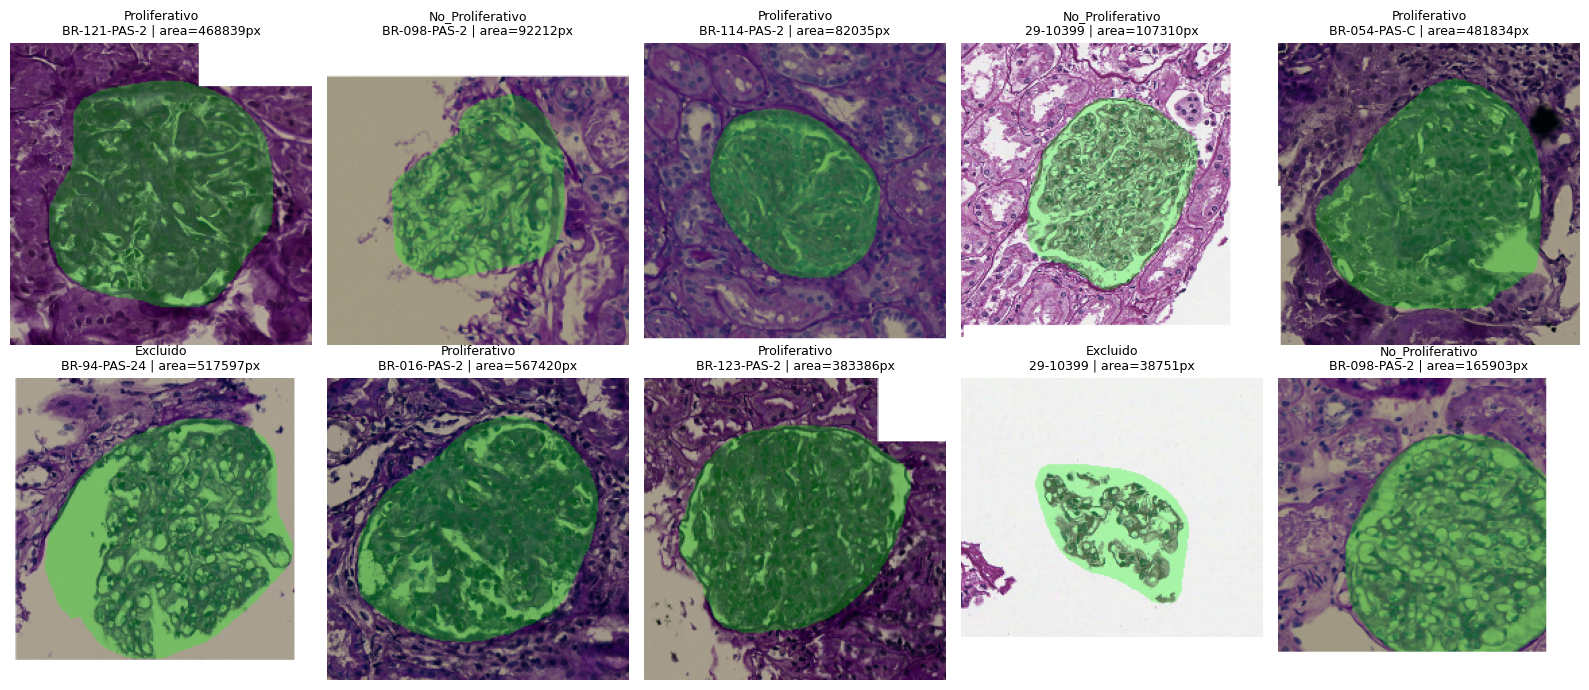

✓ Saved to Salidas\Clasificador\viz_10_glomeruli.png


In [16]:
# === VIZ-A: 10 glomerulos del dataset con sus máscaras ===
print("VIZ-A: 10 reconstructed glomeruli with masks")
if 'manifest_df' not in globals() or manifest_df is None or len(manifest_df) == 0:
    print("⚠️ manifest_df no existe o está vacío. Ejecuta primero la celda 'Build or Load Glomerulus Manifest' o el entrenamiento.")
else:
    random.seed(42)
    sample_indices = random.sample(range(len(manifest_df)), min(10, len(manifest_df)))
    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    axes = axes.flatten()
    for plot_idx, df_idx in enumerate(sample_indices):
        row = manifest_df.iloc[df_idx]
        try:
            rgb = load_rgb_image(row['fused_crop_path'])
            crop_rgb = rgb
            crop_rgb = cv2.resize(crop_rgb, (CONFIG['input_size'], CONFIG['input_size']))
            mask_mc = cv2.imread(row['fused_mask_path'], cv2.IMREAD_GRAYSCALE)
            mask_crop = mask_mc
            mask_crop = cv2.resize(mask_crop, (CONFIG['input_size'], CONFIG['input_size']), interpolation=cv2.INTER_NEAREST)
            class_mask = (mask_crop == int(row['gray_value'])).astype(np.uint8)
            if class_mask.sum() == 0:
                class_mask = (mask_crop > 0).astype(np.uint8)
            img_with_mask = make_mask_overlay(crop_rgb, class_mask, color=(0, 255, 0), alpha=0.3)
            area_px = int(row['area_px']) if 'area_px' in row and pd.notna(row['area_px']) else int(class_mask.sum())
            axes[plot_idx].imshow(img_with_mask)
            axes[plot_idx].set_title(
                f"{row['class_name']}\n{row['slide_id'][:12]} | area={area_px}px",
                fontsize=9,
            )
            axes[plot_idx].axis('off')
        except Exception as e:
            axes[plot_idx].text(0.5, 0.5, f"Error:\n{str(e)[:30]}", ha='center', va='center', fontsize=8)
            axes[plot_idx].axis('off')
    for ax in axes[len(sample_indices):]:
        ax.axis('off')
    plt.tight_layout()
    Path(CONFIG['output_dir']).mkdir(parents=True, exist_ok=True)
    plt.savefig(Path(CONFIG['output_dir']) / 'viz_10_glomeruli.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved to {Path(CONFIG['output_dir']) / 'viz_10_glomeruli.png'}")


VIZ-B: Data augmentation effects (mask overlay in red)


c:\Users\proyecto_final\Documents\Proyecto_Final_Glomerulos\env\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


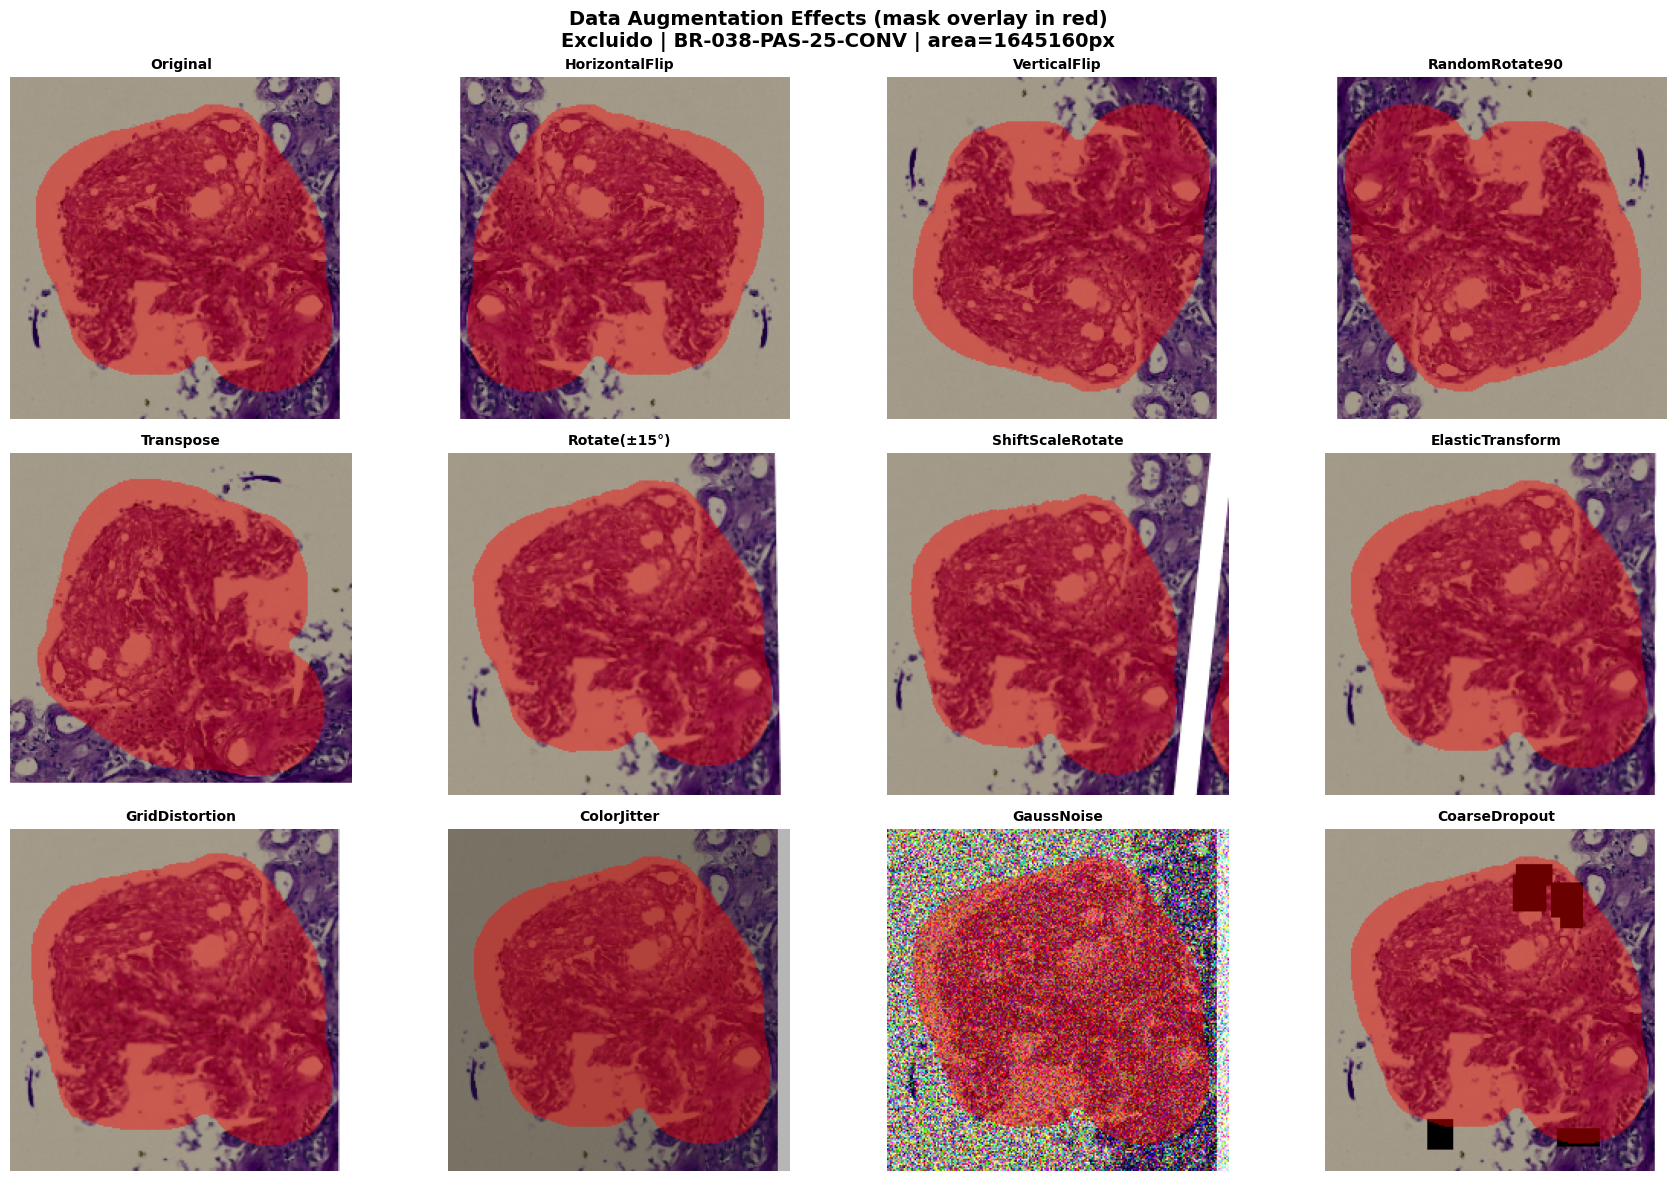

✓ Saved to Salidas\Clasificador\viz_augmentation_effects.png


In [17]:
# === VIZ-B: Data augmentation effects sobre glomérulo + máscara ===
print("VIZ-B: Data augmentation effects (mask overlay in red)")

if 'manifest_df' not in globals() or manifest_df is None or len(manifest_df) == 0:
    print("⚠️ manifest_df no existe o está vacío. Ejecuta primero la celda 'Build or Load Glomerulus Manifest'.")
else:
    train_manifest = manifest_df[manifest_df['split'] == 'train'].copy()
    if 'coverage_pct' in train_manifest.columns:
        train_manifest = train_manifest[train_manifest['coverage_pct'].fillna(100) >= 80]
    if 'component_touches_edge' in train_manifest.columns:
        train_manifest = train_manifest[~train_manifest['component_touches_edge'].fillna(False).astype(bool)]

    if len(train_manifest) == 0:
        print("⚠️ No train samples available for augmentation visualization")
    else:
        # Prefer a large, clean glomerulus so geometric augmentations are easy to inspect.
        if 'area_px' in train_manifest.columns:
            row = train_manifest.sort_values('area_px', ascending=False).iloc[0]
        else:
            row = train_manifest.sample(1, random_state=CONFIG['seed']).iloc[0]

        crop_rgb = load_rgb_image(row['fused_crop_path']).astype(np.uint8)
        crop_mask = cv2.imread(row['fused_mask_path'], cv2.IMREAD_GRAYSCALE)
        crop_mask = (crop_mask == int(row['gray_value'])).astype(np.uint8)
        if crop_mask.sum() == 0:
            crop_mask = (crop_mask > 0).astype(np.uint8)

        crop_rgb = cv2.resize(crop_rgb, (CONFIG['input_size'], CONFIG['input_size']), interpolation=cv2.INTER_LINEAR)
        crop_mask = cv2.resize(crop_mask, (CONFIG['input_size'], CONFIG['input_size']), interpolation=cv2.INTER_NEAREST)

        def apply_aug(name, transform):
            if transform is None:
                return name, crop_rgb, crop_mask
            augmented = A.Compose([transform], additional_targets={'mask': 'mask'})(image=crop_rgb, mask=crop_mask)
            return name, augmented['image'], augmented['mask']

        aug_specs = [
            ('Original', None),
            ('HorizontalFlip', A.HorizontalFlip(p=1.0)),
            ('VerticalFlip', A.VerticalFlip(p=1.0)),
            ('RandomRotate90', A.RandomRotate90(p=1.0)),
            ('Transpose', A.Transpose(p=1.0)),
            ('Rotate(±15°)', A.Rotate(limit=15, border_mode=cv2.BORDER_REFLECT, p=1.0)),
            ('ShiftScaleRotate', A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.12, rotate_limit=15, border_mode=cv2.BORDER_REFLECT, p=1.0)),
            ('ElasticTransform', A.ElasticTransform(alpha=25, sigma=5, border_mode=cv2.BORDER_REFLECT, p=1.0)),
            ('GridDistortion', A.GridDistortion(num_steps=5, distort_limit=0.25, border_mode=cv2.BORDER_REFLECT, p=1.0)),
            ('ColorJitter', A.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.20, hue=0.05, p=1.0)),
            ('GaussNoise', A.GaussNoise(p=1.0)),
            ('CoarseDropout', A.CoarseDropout(num_holes_range=(4, 8), hole_height_range=(12, 28), hole_width_range=(12, 28), p=1.0)),
        ]

        fig, axes = plt.subplots(3, 4, figsize=(18, 12))
        axes = axes.flatten()
        for ax, (name, transform) in zip(axes, aug_specs):
            try:
                aug_name, aug_rgb, aug_mask = apply_aug(name, transform)
                overlay = make_mask_overlay(aug_rgb.astype(np.uint8), (aug_mask > 0).astype(np.uint8), color=(255, 0, 0), alpha=0.42)
                ax.imshow(overlay)
                ax.set_title(aug_name, fontsize=10, fontweight='bold')
                ax.axis('off')
            except Exception as e:
                ax.text(0.5, 0.5, f"{name}\nError:\n{str(e)[:45]}", ha='center', va='center', fontsize=8)
                ax.axis('off')

        area_px = int(row['area_px']) if 'area_px' in row and pd.notna(row['area_px']) else int(crop_mask.sum())
        plt.suptitle(
            f"Data Augmentation Effects (mask overlay in red)\n{row['class_name']} | {row['slide_id']} | area={area_px}px",
            fontsize=14,
            fontweight='bold',
        )
        plt.tight_layout()
        Path(CONFIG['output_dir']).mkdir(parents=True, exist_ok=True)
        out_path = Path(CONFIG['output_dir']) / 'viz_augmentation_effects.png'
        plt.savefig(out_path, dpi=120, bbox_inches='tight')
        plt.show()
        print(f"✓ Saved to {out_path}")


In [18]:
# 4. Create datasets
# Requires manifest_df (from the manifest cell or train_classifier) and U-Net preprocessing stats.
if 'manifest_df' not in globals() or manifest_df is None or len(manifest_df) == 0:
    print("⚠️ manifest_df no existe o está vacío. Ejecuta primero la celda 'Build or Load Glomerulus Manifest'.")
elif not all(name in globals() for name in ['channel_means', 'channel_stds', 'reinhard_stats']):
    print("⚠️ Faltan channel_means/channel_stds/reinhard_stats. Ejecuta primero la celda de carga del checkpoint U-Net.")
else:
    dataset_train = GlomeruliClassificationDataset(
        manifest_df, CONFIG['images_dir'], CONFIG['masks_dir'], split='train',
        channel_means=channel_means, channel_stds=channel_stds, reinhard=reinhard_stats, config=CONFIG
    )
    dataset_val = GlomeruliClassificationDataset(
        manifest_df, CONFIG['images_dir'], CONFIG['masks_dir'], split='val',
        channel_means=channel_means, channel_stds=channel_stds, reinhard=reinhard_stats, config=CONFIG
    )
    dataset_test = GlomeruliClassificationDataset(
        manifest_df, CONFIG['images_dir'], CONFIG['masks_dir'], split='test',
        channel_means=channel_means, channel_stds=channel_stds, reinhard=reinhard_stats, config=CONFIG
    )
    loader_train, loader_val, loader_test = create_classification_dataloaders(
        dataset_train, dataset_val, dataset_test, CONFIG
    )
    print(f"✓ Dataloaders created: train={len(loader_train)}, val={len(loader_val)}, test={len(loader_test)}")


✓ Dataloaders created: train=39, val=6, test=11


In [19]:
# 5. Train classifier
print("\n" + "="*80)
print("TRAINING CLASSIFIER")
print("="*80)
model, train_history, manifest_df = train_classifier(CONFIG)
print(f"\n✓ Training complete!")
print(f"  Best balanced_acc: {train_history['best_balanced_acc']:.4f}")
print(f"  Manifest instances: {len(manifest_df)}")
print(f"    Train: {len(manifest_df[manifest_df['split']=='train'])}")
print(f"    Val:   {len(manifest_df[manifest_df['split']=='val'])}")
print(f"    Test:  {len(manifest_df[manifest_df['split']=='test'])}")



TRAINING CLASSIFIER

Loading U-Net checkpoint: unet_binary_20260513_072214_best.pth
  ✓ Channel means: [0.5249426116573582, 0.4619087558025785, 0.4945691148938925]
  ✓ Channel stds: [0.12682547154319532, 0.15825028652078063, 0.06188548903405716]
✓ Split biopsias: train=49, val=11, test=11
✓ Loaded cached manifest: Salidas\Clasificador\manifest.csv (1729 instances)

=== MANIFEST DISTRIBUTION ===
Total instances: 1729

By class and split:
split             test  train  val   All
class_name                              
Esclerosado         14    157   15   186
Excluido            67    196   32   295
No_Proliferativo   209    495   53   757
Proliferativo       34    373   84   491
All                324   1221  184  1729

Top 10 biopsies by instance count:
slide_id
27-10041                   80
18-139                     74
BR-098-PAS-25-CONV         66
BR-94-PAS-24-CONV          58
BR-038-PAS-25-CONV         50
BR-123-PAS-24-OTRA-CONV    49
BR-105-PAS-25-CONV         48
29-10399        

C:\Users\proyecto_final\AppData\Local\Temp\ipykernel_8684\2650140367.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)



Training default | Epochs: 60, Patience: 10, LR: 0.001
  Train: 1221 | Val: 184 | Test: 324


train:   0%|          | 0/39 [00:00<?, ?it/s]C:\Users\proyecto_final\AppData\Local\Temp\ipykernel_8684\2650140367.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
C:\Users\proyecto_final\AppData\Local\Temp\ipykernel_8684\2650140367.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch   1/60 | Train Loss: 2.6252 | Val Loss: 2.6377 | Train Acc: 0.482 | Val Acc: 0.429 | LR: 1.00e-03 | ★ best


...

train:   0%|          | 0/39 [00:00<?, ?it/s]C:\Users\proyecto_final\AppData\Local\Temp\ipykernel_8684\2650140367.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
C:\Users\proyecto_final\AppData\Local\Temp\ipykernel_8684\2650140367.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch  12/60 | Train Loss: 0.1440 | Val Loss: 1.3995 | Train Acc: 0.956 | Val Acc: 0.605 | LR: 3.46e-04 | wait 9/10


train:   0%|          | 0/39 [00:00<?, ?it/s]C:\Users\proyecto_final\AppData\Local\Temp\ipykernel_8684\2650140367.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch  13/60 | Train Loss: 0.0927 | Val Loss: 1.4068 | Train Acc: 0.971 | Val Acc: 0.583 | LR: 2.07e-04 | wait 10/10
→ Early stopping at epoch 13


✓ default complete | Test Acc: 0.6541

TRAINING COMPLETE
  Best test balanced_accuracy: 0.6541
  Test Precision: 0.5412
  Test Recall:    0.6541
  Test F1-Score:  0.5481
  Best model saved: Salidas\Clasificador\best_model_default.pth


✓ Training complete!
  Best balanced_acc: 0.6541
  Manifest instances: 1729
    Train: 1221
    Val:   184
    Test:  324


VIZ-C: Predictions vs Ground Truth


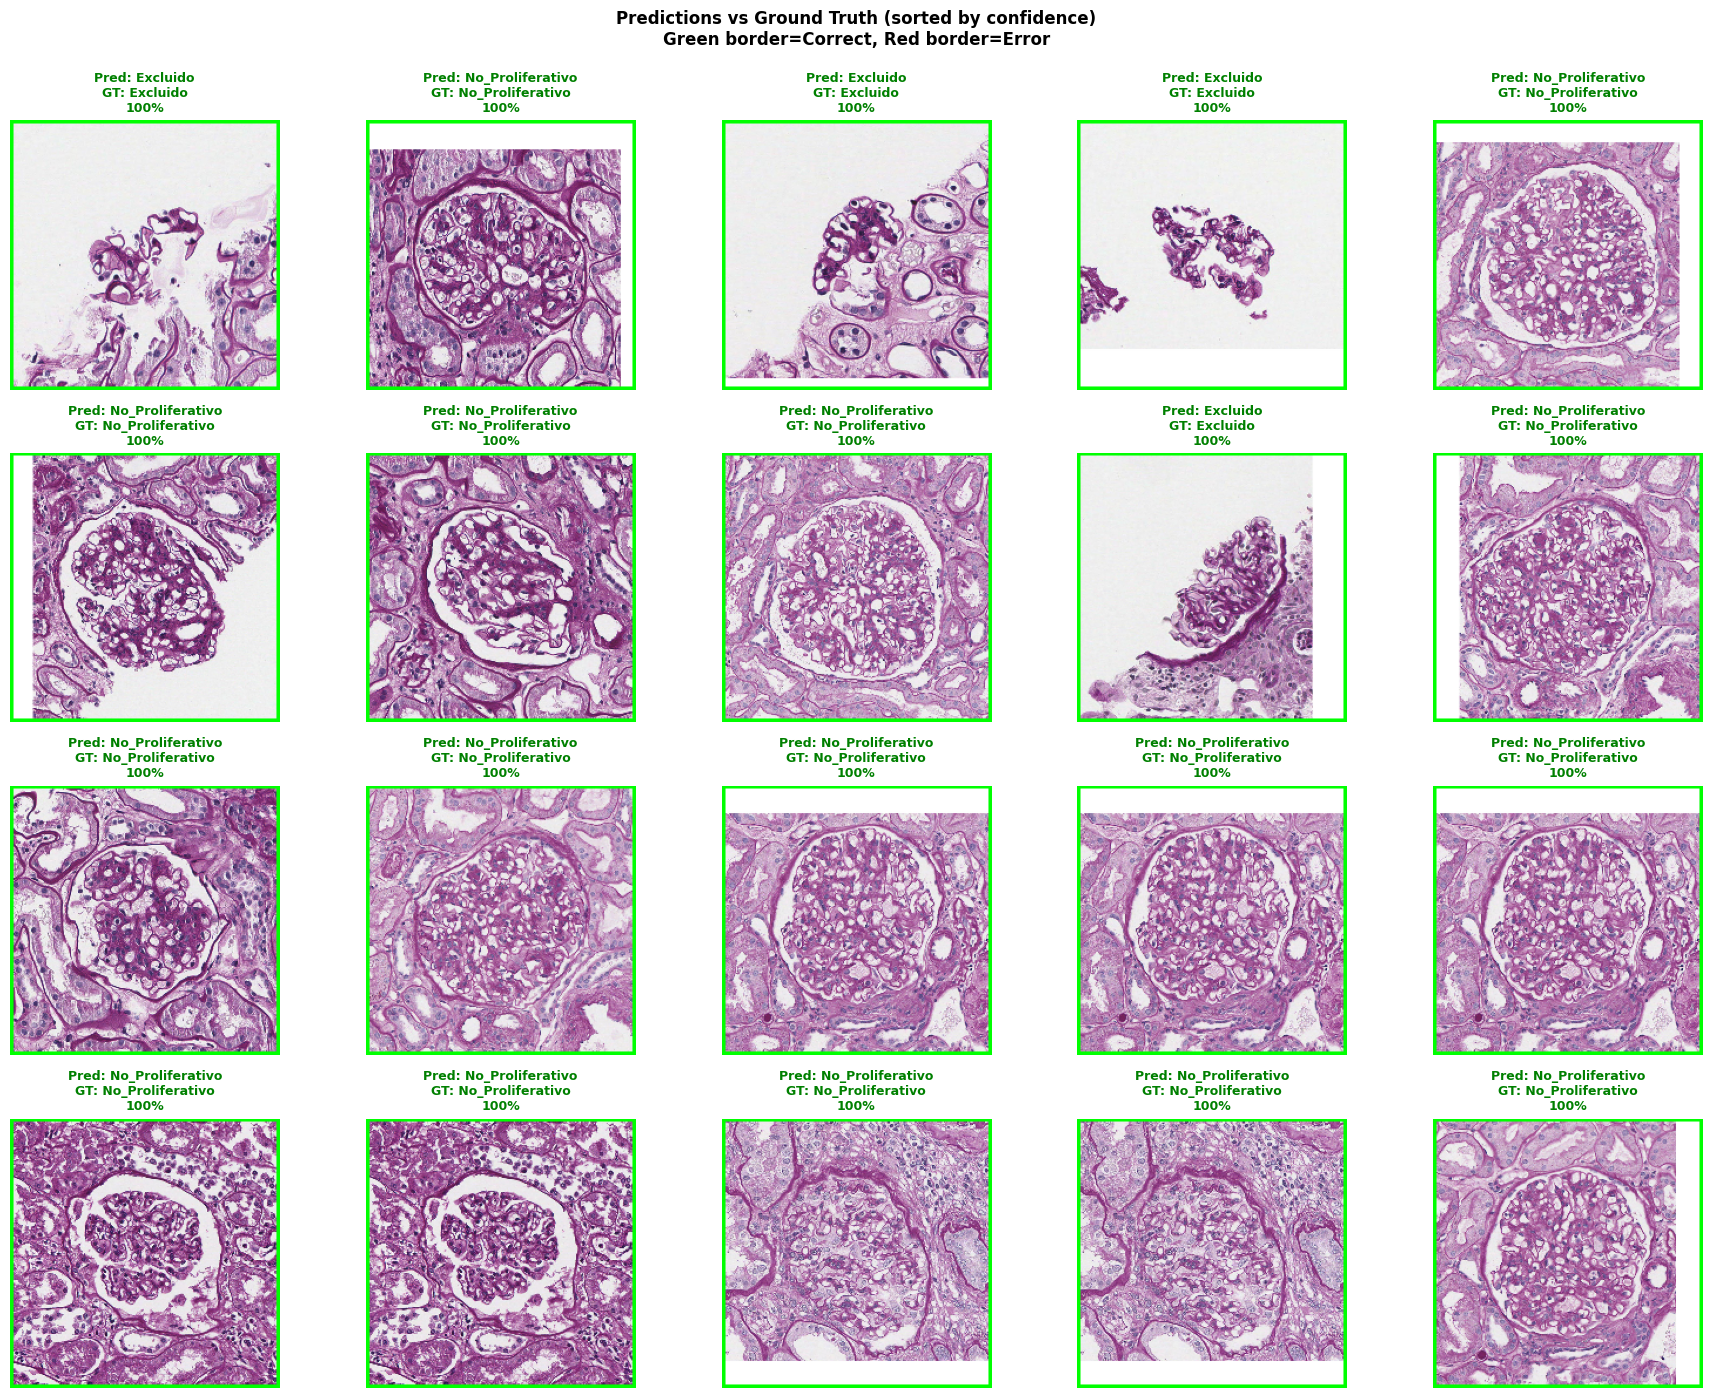

✓ Saved to Salidas\Clasificador\viz_predictions_vs_gt.png


In [21]:
# === VIZ-C: Predicciones vs Ground Truth (20 crops) ===
print("VIZ-C: Predictions vs Ground Truth")
required_names = ['manifest_df', 'model', 'channel_means', 'channel_stds', 'reinhard_stats']
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    print(f"⚠️ Faltan variables requeridas: {missing_names}. Ejecuta primero manifest/checkpoint/training.")
elif manifest_df is None or len(manifest_df) == 0:
    print("⚠️ manifest_df está vacío. Ejecuta primero la celda 'Build or Load Glomerulus Manifest' o el entrenamiento.")
else:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    preprocessing_params = {
        'images_dir': CONFIG['images_dir'],
        'masks_dir': CONFIG['masks_dir'],
        'input_size': CONFIG['input_size'],
        'mask_size': CONFIG['mask_size'],
        'margin_ratio': CONFIG['margin_ratio'],
        'channel_means': channel_means,
        'channel_stds': channel_stds,
        'reinhard': reinhard_stats,
    }
    test_manifest = manifest_df[manifest_df['split'] == 'test'].reset_index(drop=True)
    if len(test_manifest) == 0:
        print("⚠️ No test samples available")
    else:
        dataset_test_viz = GlomeruliClassificationDataset(
            test_manifest,
            config=CONFIG,
            split='test',
            **preprocessing_params,
        )
        loader_test_viz = DataLoader(dataset_test_viz, batch_size=1, shuffle=False, num_workers=0)
        model.eval()
        all_predictions = []
        all_labels = []
        all_probs = []
        with torch.no_grad():
            for batch in tqdm(loader_test_viz, desc="Inferencing", leave=False):
                x, y = batch['image'].to(device), batch['label'].to(device)
                logits = model(x)
                probs = torch.softmax(logits, dim=1)
                preds = torch.argmax(logits, dim=1)
                all_predictions.append(preds.cpu().numpy()[0])
                all_labels.append(y.cpu().numpy()[0])
                all_probs.append(probs.cpu().numpy()[0])
        all_predictions = np.array(all_predictions)
        all_labels = np.array(all_labels)
        all_probs = np.array(all_probs)
        confidences = np.max(all_probs, axis=1)
        sorted_idx = np.argsort(-confidences)
        n_show = min(20, len(sorted_idx))
        sorted_idx = sorted_idx[:n_show]
        fig, axes = plt.subplots(4, 5, figsize=(18, 14))
        axes = axes.flatten()
        for plot_idx, manifest_idx in enumerate(sorted_idx):
            row = test_manifest.iloc[manifest_idx]
            pred_class_id = int(all_predictions[manifest_idx])
            label_class_id = int(all_labels[manifest_idx])
            confidence = float(confidences[manifest_idx])
            is_correct = (pred_class_id == label_class_id)
            try:
                crop_rgb = load_rgb_image(row['fused_crop_path'])
                crop_rgb = cv2.resize(crop_rgb, (CONFIG['input_size'], CONFIG['input_size']))
                border_color = (0, 255, 0) if is_correct else (255, 0, 0)
                crop_with_border = cv2.copyMakeBorder(crop_rgb, 3, 3, 3, 3, cv2.BORDER_CONSTANT, value=border_color)
                axes[plot_idx].imshow(crop_with_border)
                pred_name = CLASS_NAMES[pred_class_id]
                label_name = CLASS_NAMES[label_class_id]
                axes[plot_idx].set_title(
                    f"Pred: {pred_name}\nGT: {label_name}\n{confidence:.0%}",
                    fontsize=9,
                    color='green' if is_correct else 'red',
                    fontweight='bold' if is_correct else 'normal',
                )
                axes[plot_idx].axis('off')
            except Exception as e:
                axes[plot_idx].text(0.5, 0.5, f"Error:\n{str(e)[:25]}", ha='center', va='center', fontsize=8)
                axes[plot_idx].axis('off')
        for ax in axes[n_show:]:
            ax.axis('off')
        plt.suptitle(
            "Predictions vs Ground Truth (sorted by confidence)\nGreen border=Correct, Red border=Error",
            fontsize=12,
            fontweight='bold',
            y=0.995,
        )
        plt.tight_layout()
        Path(CONFIG['output_dir']).mkdir(parents=True, exist_ok=True)
        plt.savefig(Path(CONFIG['output_dir']) / 'viz_predictions_vs_gt.png', dpi=100, bbox_inches='tight')
        plt.show()
        print(f"✓ Saved to {Path(CONFIG['output_dir']) / 'viz_predictions_vs_gt.png'}")
